# City Segmentation Using Deep Learning using SegFormer-B2

### Semantic Segmentation of Urban Satellite Images

---

### Project Description

This project aims to perform semantic segmentation of urban satellite imagery using the SegFormer-B2 architecture. The model is trained on the LoveDA Urban dataset to classify each pixel into one of the predefined land-cover classes. The generated segmentation maps can support Geographic Information System (GIS) applications such as urban planning, land-use mapping, environmental monitoring, and infrastructure management. The performance of the trained model is evaluated using the Mean Intersection over Union (mIoU) metric.

# Introduction

- This project focuses on **city (urban land-cover) segmentation** using the **SegFormer-B2** deep learning model on high-resolution satellite images from the **LoveDA Urban** dataset.

- The objective is to perform **pixel-level classification** of satellite images into seven land-cover classes: Background, Building, Road, Water, Barren, Forest, and Agricultural.

- Automated semantic segmentation provides accurate and efficient urban mapping, supporting GIS applications such as urban planning, land-use analysis, and environmental monitoring.

- **SegFormer-B2**, a transformer-based semantic segmentation model, is used to learn both local and global features for improved segmentation performance.

- The trained model is evaluated using **Mean Intersection over Union (mIoU)** to measure the accuracy of the predicted segmentation masks.

## Objectives

- Develop an automated deep learning model for urban semantic segmentation.
- Train the SegFormer-B2 model using the LoveDA Urban dataset.
- Generate pixel-level segmentation maps for urban land-cover classes.
- Evaluate segmentation performance using Mean Intersection over Union (mIoU).
- Demonstrate the applicability of transformer-based segmentation models for remote sensing and GIS applications.

## Methodology

The overall methodology consists of five major stages:

1. **Dataset Preparation:** Collect the LoveDA Urban dataset containing satellite images and corresponding pixel-level annotation masks.

2. **Data Preprocessing:** Resize images, normalize pixel values, encode segmentation masks, and prepare training and validation datasets.

3. **Model Training:** Fine-tune the pretrained SegFormer-B2 model using the processed dataset with supervised learning.

4. **Model Evaluation:** Evaluate the trained model using the Mean Intersection over Union (mIoU) metric and visualize predicted segmentation masks.

5. **Result Analysis:** Compare the predicted masks with the ground-truth annotations to assess segmentation quality and identify strengths and limitations of the model.

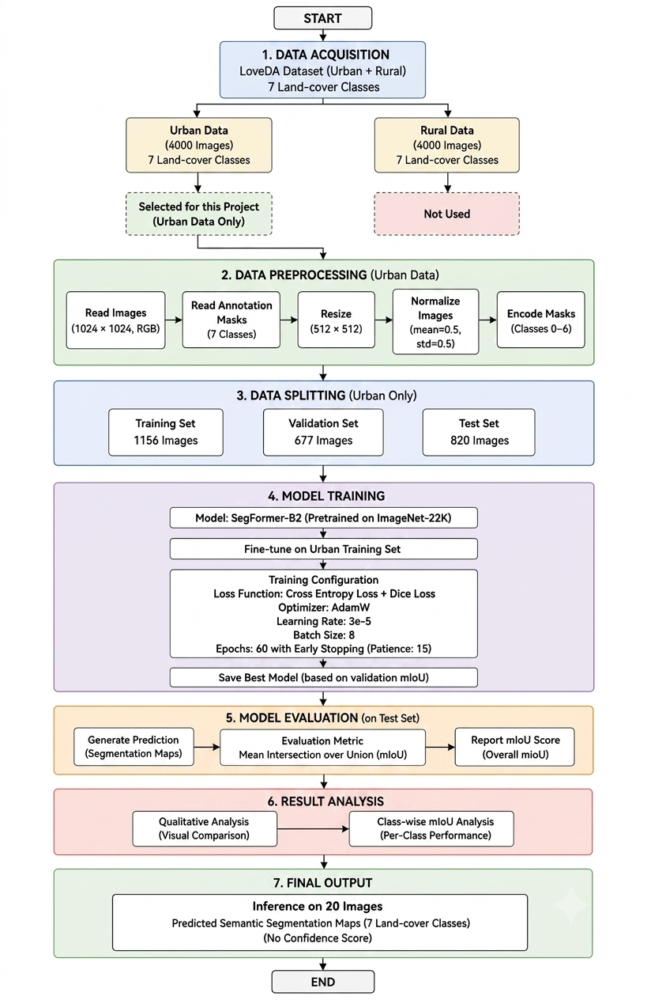

In [1]:
from IPython.display import Image, display

display(Image("/kaggle/input/datasets/sagunraii/methodology/methodology.png"))

In [2]:
# Kaggle: make sure Accelerator = GPU (Settings -> Accelerator -> GPU T4 x1 / P100)
!nvidia-smi --query-gpu=name,memory.total,memory.used,memory.free --format=csv
!pip install -q -U transformers accelerate


name, memory.total [MiB], memory.used [MiB], memory.free [MiB]
Tesla T4, 15360 MiB, 0 MiB, 14912 MiB
Tesla T4, 15360 MiB, 0 MiB, 14912 MiB
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 93.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 31.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 kB 36.7 MB/s eta 0:00:00


## 2. Imports

In [3]:
import os
import math 
import gc
import time
import random
from glob import glob

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import amp
from torch.utils.data import Dataset, DataLoader
from torch.amp import GradScaler

import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm.auto import tqdm

from transformers import (
    SegformerForSemanticSegmentation,
    get_cosine_schedule_with_warmup,
)

import albumentations as A
from albumentations.pytorch import ToTensorV2


# ---------------- Reproducibility ----------------
SEED = 42

def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


seed_everything()

print(f"Torch: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Torch: 2.10.0+cu128
CUDA Available: True
GPU: Tesla T4


## 3. Config

In [4]:
class CFG:
    # ================= Dataset =================
    DATA_ROOT = "/kaggle/input/datasets/sagunraii/loveda-for-semantic-segmentaion"

    TRAIN_IMG_DIR = f"{DATA_ROOT}/Train/Train/Urban/images_png"
    TRAIN_MASK_DIR = f"{DATA_ROOT}/Train/Train/Urban/masks_png"

    VAL_IMG_DIR = f"{DATA_ROOT}/Val/Val/Urban/images_png"
    VAL_MASK_DIR = f"{DATA_ROOT}/Val/Val/Urban/masks_png"

    TEST_IMG_DIR = f"{DATA_ROOT}/Test/Test/Urban/images_png"

    # ================= Model =================
    MODEL_CKPT = "nvidia/segformer-b2-finetuned-ade-512-512"
    NUM_CLASSES = 7
    IMG_SIZE = 640

    # ================= Training =================
    BATCH_SIZE = 4
    VAL_BATCH_SIZE = 4

    NUM_WORKERS = 4

    EPOCHS = 80

    LR = 2e-5
    WEIGHT_DECAY = 1e-2

    WARMUP_RATIO = 0.05

    IGNORE_INDEX = 255

    GRAD_CLIP = 1.0

    ACCUM_STEPS = 2

    MIXED_PRECISION = True

    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    OUT_DIR = "/kaggle/working/segformer_b2_loveda"

    CKPT_BEST = f"{OUT_DIR}/best_model.pth"

    NUM_INFER_SAMPLES = 20

os.makedirs(CFG.OUT_DIR, exist_ok=True)

CLASS_NAMES = [
    "background",
    "building",
    "road",
    "water",
    "barren",
    "forest",
    "agriculture",
]

CLASS_COLORS = np.array([
    [255,255,255],
    [255,0,0],
    [255,255,0],
    [0,0,255],
    [159,129,183],
    [0,255,0],
    [255,195,128],
], dtype=np.uint8)

print("Device:", CFG.DEVICE)

Device: cuda


## 4. Dataset & Augmentations

In [5]:
def build_transforms(img_size, train=True):
    if train:
        return A.Compose([
            # ---------------- Geometry ----------------
            A.RandomResizedCrop(
                size=(img_size, img_size),
                scale=(0.8, 1.0),
                ratio=(0.9, 1.1),
                p=1.0,
            ),

            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.2),

            A.ShiftScaleRotate(
                shift_limit=0.05,
                scale_limit=0.10,
                rotate_limit=10,
                border_mode=cv2.BORDER_CONSTANT,
                value=0,
                mask_value=255,
                p=0.30,
            ),

            # ---------------- Appearance ----------------
            A.ColorJitter(
                brightness=0.10,
                contrast=0.10,
                saturation=0.10,
                hue=0.02,
                p=0.40,
            ),

            A.RandomBrightnessContrast(
                brightness_limit=0.15,
                contrast_limit=0.15,
                p=0.30,
            ),

            A.RandomGamma(
                gamma_limit=(90, 110),
                p=0.20,
            ),

            A.GaussNoise(
                p=0.10,
            ),

            # ---------------- Regularization ----------------
            A.CoarseDropout(
                max_holes=3,
                max_height=16,
                max_width=16,
                fill_value=0,
                mask_fill_value=255,
                p=0.15,
            ),

            # ---------------- Normalize ----------------
            A.Normalize(
                mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225),
            ),

            ToTensorV2(),
        ])

    # ---------------- Validation / Test ----------------
    return A.Compose([
        A.Resize(img_size, img_size),

        A.Normalize(
            mean=(0.485, 0.456, 0.406),
            std=(0.229, 0.224, 0.225),
        ),

        ToTensorV2(),
    ])


class LoveDADataset(Dataset):
    """
    LoveDA Dataset

    Raw mask labels:
        0 -> Ignore
        1-7 -> Valid classes

    Remapped labels:
        Ignore -> 255
        1-7 -> 0-6
    """

    def __init__(self,
                 img_dir,
                 mask_dir=None,
                 transform=None,
                 ignore_index=255):

        self.img_paths = sorted(
            glob(os.path.join(img_dir, "*.png")) +
            glob(os.path.join(img_dir, "*.jpg")) +
            glob(os.path.join(img_dir, "*.tif"))
        )

        assert len(self.img_paths) > 0, f"No images found in {img_dir}"

        self.mask_dir = mask_dir
        self.transform = transform
        self.ignore_index = ignore_index

    def __len__(self):
        return len(self.img_paths)

    def _remap_mask(self, mask):
        mask = mask.astype(np.int64)

        remapped = np.full(mask.shape, self.ignore_index, dtype=np.int64)

        valid = mask > 0
        remapped[valid] = mask[valid] - 1

        return remapped

    def __getitem__(self, idx):

        img_path = self.img_paths[idx]

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        filename = os.path.basename(img_path)

        if self.mask_dir is not None:

            mask_path = os.path.join(self.mask_dir, filename)

            mask = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)

            mask = self._remap_mask(mask)

        else:

            mask = np.zeros(image.shape[:2], dtype=np.int64)

        if self.transform is not None:

            augmented = self.transform(
                image=image,
                mask=mask,
            )

            image = augmented["image"]
            mask = augmented["mask"]

        return image, mask.long(), filename

## 5. DataLoaders

In [6]:
train_tf = build_transforms(CFG.IMG_SIZE, train=True)
val_tf   = build_transforms(CFG.IMG_SIZE, train=False)

train_ds = LoveDADataset(CFG.TRAIN_IMG_DIR, CFG.TRAIN_MASK_DIR, transform=train_tf, ignore_index=CFG.IGNORE_INDEX)
val_ds   = LoveDADataset(CFG.VAL_IMG_DIR,   CFG.VAL_MASK_DIR,   transform=val_tf,   ignore_index=CFG.IGNORE_INDEX)

test_ds = LoveDADataset(
    CFG.TEST_IMG_DIR,
    None,
    transform=val_tf,
    ignore_index=CFG.IGNORE_INDEX
)

train_loader = DataLoader(train_ds, batch_size=CFG.BATCH_SIZE, shuffle=True,
                           num_workers=CFG.NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds, batch_size=CFG.VAL_BATCH_SIZE, shuffle=False,
                           num_workers=CFG.NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=CFG.VAL_BATCH_SIZE, shuffle=False,
                           num_workers=CFG.NUM_WORKERS, pin_memory=True)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")


Train: 1156 | Val: 677 | Test: 820


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipykernel_58/1979581366.py:15: UserWarning: Argument(s) 'value, mask_value' are not valid for transform ShiftScaleRotate
  A.ShiftScaleRotate(
/tmp/ipykernel_58/1979581366.py:50: UserWarning: Argument(s) 'max_holes, max_height, max_width, fill_value, mask_fill_value' are not valid for transform CoarseDropout
  A.CoarseDropout(


## 6. Visualize a batch of training data

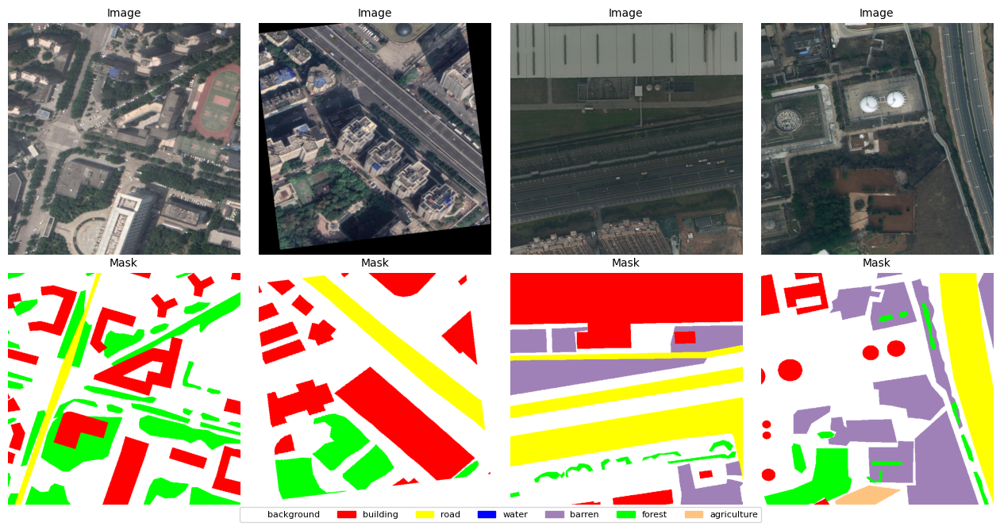

In [7]:
def denormalize(img_tensor, mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)):
    img = img_tensor.clone().permute(1, 2, 0).numpy()
    img = img * np.array(std) + np.array(mean)
    return np.clip(img, 0, 1)

def mask_to_rgb(mask, ignore_index=255):
    mask = mask.copy()
    rgb = np.zeros((*mask.shape, 3), dtype=np.uint8)
    for cls_id, color in enumerate(CLASS_COLORS):
        rgb[mask == cls_id] = color
    rgb[mask == ignore_index] = [0, 0, 0]
    return rgb

sample_imgs, sample_masks, _ = next(iter(train_loader))
n_show = min(6, len(sample_imgs))

fig, axes = plt.subplots(2, n_show, figsize=(3.2 * n_show, 6.5))
for i in range(n_show):
    axes[0, i].imshow(denormalize(sample_imgs[i]))
    axes[0, i].set_title("Image", fontsize=10)
    axes[0, i].axis("off")
    axes[1, i].imshow(mask_to_rgb(sample_masks[i].numpy(), CFG.IGNORE_INDEX))
    axes[1, i].set_title("Mask", fontsize=10)
    axes[1, i].axis("off")

legend_patches = [mpatches.Patch(color=np.array(c) / 255, label=n) for c, n in zip(CLASS_COLORS, CLASS_NAMES)]
fig.legend(handles=legend_patches, loc="lower center", ncol=7, fontsize=8, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
plt.show()


## 7. Model setup — SegFormer-B2

In [8]:
# ===============================
# SegFormer-B2 Model
# ===============================

model = SegformerForSemanticSegmentation.from_pretrained(
    CFG.MODEL_CKPT,
    num_labels=CFG.NUM_CLASSES,
    ignore_mismatched_sizes=True,
)

# Enable gradient checkpointing (reduces GPU memory usage)
model.gradient_checkpointing_enable()

model.to(CFG.DEVICE)

print(f"Model: {CFG.MODEL_CKPT}")
print(f"Classes: {model.config.num_labels}")

# Parameter statistics
n_params = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total Parameters     : {n_params/1e6:.2f} M")
print(f"Trainable Parameters : {n_trainable/1e6:.2f} M")

config.json: 0.00B [00:00, ?B/s]

[transformers] You passed `num_labels=7` which is incompatible to the `id2label` map of length `150`.


pytorch_model.bin:   0%|          | 0.00/110M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/380 [00:00<?, ?it/s]

[transformers] SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b2-finetuned-ade-512-512
Key                           | Status   |                                                                                                     
------------------------------+----------+-----------------------------------------------------------------------------------------------------
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150]) vs model:torch.Size([7])                      
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150, 768, 1, 1]) vs model:torch.Size([7, 768, 1, 1])

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


Model: nvidia/segformer-b2-finetuned-ade-512-512
Classes: 7
Total Parameters     : 27.35 M
Trainable Parameters : 27.35 M


## 8. Loss, optimizer, scheduler, AMP scaler

In [9]:
# =====================================================
# DICE LOSS
# =====================================================
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-5, ignore_index=255):
        super().__init__()
        self.smooth = smooth
        self.ignore_index = ignore_index

    def forward(self, logits, targets):
        num_classes = logits.shape[1]

        probs = torch.softmax(logits, dim=1)

        valid_mask = targets != self.ignore_index

        targets = targets.clone()
        targets[~valid_mask] = 0

        target_one_hot = F.one_hot(
            targets,
            num_classes=num_classes
        ).permute(0, 3, 1, 2).float()

        valid_mask = valid_mask.unsqueeze(1)

        probs = probs * valid_mask
        target_one_hot = target_one_hot * valid_mask

        intersection = (probs * target_one_hot).sum(dim=(0, 2, 3))
        union = probs.sum(dim=(0, 2, 3)) + target_one_hot.sum(dim=(0, 2, 3))

        dice = (2.0 * intersection + self.smooth) / (union + self.smooth)

        return 1.0 - dice.mean()


# =====================================================
# COMBINED LOSS
# =====================================================
class CombinedLoss(nn.Module):
    def __init__(
        self,
        ignore_index=255,
        ce_weight=1.0,
        dice_weight=0.5
    ):
        super().__init__()

        self.ce = nn.CrossEntropyLoss(
            ignore_index=ignore_index,
            label_smoothing=0.05
        )

        self.dice = DiceLoss(ignore_index=ignore_index)

        self.ce_weight = ce_weight
        self.dice_weight = dice_weight

    def forward(self, logits, targets):

        ce_loss = self.ce(logits, targets)
        dice_loss = self.dice(logits, targets)

        total_loss = (
            self.ce_weight * ce_loss +
            self.dice_weight * dice_loss
        )

        return total_loss


# =====================================================
# LOSS FUNCTION
# =====================================================
criterion = CombinedLoss(
    ignore_index=CFG.IGNORE_INDEX,
    ce_weight=1.0,
    dice_weight=0.5
)


# =====================================================
# OPTIMIZER
# =====================================================
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=CFG.LR,
    betas=(0.9, 0.999),
    eps=1e-8,
    weight_decay=1e-2
)


# =====================================================
# LEARNING RATE SCHEDULER
# =====================================================
steps_per_epoch = math.ceil(len(train_loader) / CFG.ACCUM_STEPS)

total_steps = steps_per_epoch * CFG.EPOCHS

warmup_steps = int(total_steps * CFG.WARMUP_RATIO)

scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)


# =====================================================
# MIXED PRECISION
# =====================================================
from torch.amp import GradScaler

scaler = GradScaler(
    "cuda",
    enabled=CFG.MIXED_PRECISION
)


# =====================================================
# INFO
# =====================================================
print("=" * 60)
print("Loss Function : CrossEntropy + Dice Loss")
print("Optimizer     : AdamW")
print("Scheduler     : Cosine Warmup")
print(f"Learning Rate : {CFG.LR}")
print(f"Weight Decay  : 1e-2")
print(f"Warmup Steps  : {warmup_steps}")
print(f"Total Steps   : {total_steps}")
print(f"Batch Size    : {CFG.BATCH_SIZE}")
print(f"Accum Steps   : {CFG.ACCUM_STEPS}")
print("=" * 60)

Loss Function : CrossEntropy + Dice Loss
Optimizer     : AdamW
Scheduler     : Cosine Warmup
Learning Rate : 2e-05
Weight Decay  : 1e-2
Warmup Steps  : 580
Total Steps   : 11600
Batch Size    : 4
Accum Steps   : 2


## 9. Metrics utilities (confusion matrix → IoU / mIoU / pixel accuracy)

In [10]:
# =====================================================
# METRICS
# =====================================================

def fast_confusion_matrix(pred, target, num_classes, ignore_index=255):
    """
    Fast confusion matrix computation.
    """

    valid = target != ignore_index

    pred = pred[valid]
    target = target[valid]

    if target.numel() == 0:
        return torch.zeros(
            (num_classes, num_classes),
            dtype=torch.int64
        )

    indices = target * num_classes + pred

    cm = torch.bincount(
        indices,
        minlength=num_classes * num_classes
    ).reshape(num_classes, num_classes)

    return cm


def compute_iou_from_cm(cm):
    """
    Compute per-class IoU, Mean IoU and Pixel Accuracy.
    """

    cm = cm.to(torch.float32)

    intersection = torch.diag(cm)

    ground_truth = cm.sum(dim=1)
    prediction = cm.sum(dim=0)

    union = ground_truth + prediction - intersection

    iou = intersection / union.clamp(min=1.0)

    valid = union > 0

    if valid.any():
        miou = iou[valid].mean().item()
    else:
        miou = 0.0

    pixel_acc = (
        intersection.sum() /
        cm.sum().clamp(min=1.0)
    ).item()

    return (
        iou.cpu().numpy(),
        miou,
        pixel_acc,
    )

model.safetensors:   0%|          | 0.00/110M [00:00<?, ?B/s]

## 10. Memory logging helper

In [11]:
# =====================================================
# GPU MEMORY LOGGER
# =====================================================

def print_gpu_memory(tag=""):

    if not torch.cuda.is_available():
        return

    allocated = torch.cuda.memory_allocated() / 1024**2
    reserved = torch.cuda.memory_reserved() / 1024**2
    peak = torch.cuda.max_memory_allocated() / 1024**2

    total = torch.cuda.get_device_properties(0).total_memory / 1024**2
    free = total - reserved

    print(
        f"[{tag}] "
        f"Allocated: {allocated:.0f} MB | "
        f"Reserved: {reserved:.0f} MB | "
        f"Peak: {peak:.0f} MB | "
        f"Free: {free:.0f} MB | "
        f"Total: {total:.0f} MB"
    )

## 11. Train (optimized: AMP, grad accumulation, grad clipping)

In [12]:
# =====================================================
# TRAIN WITH FULL METRICS
# =====================================================
def train_one_epoch(
    model,
    loader,
    optimizer,
    scheduler,
    scaler,
    criterion,
    epoch,
    num_classes,
    ignore_index
):

    model.train()

    running_loss = 0.0
    n_batches = 0

    # ---------------------------------------------
    # Confusion matrix for training metrics
    # ---------------------------------------------
    cm = torch.zeros(
        num_classes,
        num_classes,
        dtype=torch.int64
    )

    optimizer.zero_grad(set_to_none=True)


    pbar = tqdm(
        loader,
        desc=f"Train {epoch:02d}",
        leave=False
    )


    for step, (imgs, masks, _) in enumerate(pbar):

        imgs = imgs.to(
            CFG.DEVICE,
            non_blocking=True
        )

        masks = masks.to(
            CFG.DEVICE,
            non_blocking=True
        )

        # ---------------------------------------------
        # Forward pass
        # ---------------------------------------------
        with torch.amp.autocast(
            device_type="cuda",
            enabled=CFG.MIXED_PRECISION
        ):

            logits = model(
                pixel_values=imgs
            ).logits

            logits = F.interpolate(
                logits,
                size=masks.shape[-2:],
                mode="bilinear",
                align_corners=False
            )

            loss = criterion(
                logits,
                masks
            )

            # Gradient accumulation
            loss_scaled = loss / CFG.ACCUM_STEPS

        # ---------------------------------------------
        # Backpropagation
        # ---------------------------------------------
        scaler.scale(
            loss_scaled
        ).backward()

        # ---------------------------------------------
        # Optimizer step
        # ---------------------------------------------
        if (
            (step + 1) % CFG.ACCUM_STEPS == 0
            or
            (step + 1) == len(loader)
        ):

            scaler.unscale_(
                optimizer
            )

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                CFG.GRAD_CLIP
            )

            scaler.step(
                optimizer
            )
            scaler.update()

            optimizer.zero_grad(
                set_to_none=True
            )

            scheduler.step()

        # ---------------------------------------------
        # Loss tracking
        # ---------------------------------------------
        running_loss += loss.item()
        n_batches += 1
        # ---------------------------------------------
        # Predictions for metrics
        # ---------------------------------------------
        preds = torch.argmax(
            logits,
            dim=1
        )
        cm += fast_confusion_matrix(
            preds.detach().flatten().cpu(),
            masks.detach().flatten().cpu(),
            num_classes,
            ignore_index
        )
        # ---------------------------------------------
        # Progress bar
        # ---------------------------------------------
        pbar.set_postfix(
            loss=f"{running_loss/n_batches:.4f}",
            lr=f"{optimizer.param_groups[0]['lr']:.2e}"
        )
    # =====================================================
    # Compute training metrics
    # =====================================================

    avg_loss = running_loss / n_batches


    train_iou, train_miou, train_pixel_acc = compute_iou_from_cm(
        cm
    )


    return {
        "loss": avg_loss,
        "miou": train_miou,
        "pixel_acc": train_pixel_acc,
        "class_iou": train_iou
    }

In [13]:
# =====================================================
# VALIDATION WITH FULL METRICS
# =====================================================
@torch.no_grad()
def evaluate(
    model,
    loader,
    criterion,
    num_classes,
    ignore_index,
    desc="Validation"
):

    model.eval()

    running_loss = 0.0
    n_batches = 0


    # ---------------------------------------------
    # Confusion matrix for validation metrics
    # ---------------------------------------------
    cm = torch.zeros(
        num_classes,
        num_classes,
        dtype=torch.int64
    )


    pbar = tqdm(
        loader,
        desc=desc,
        leave=False
    )
    for imgs, masks, _ in pbar:

        imgs = imgs.to(
            CFG.DEVICE,
            non_blocking=True
        )

        masks = masks.to(
            CFG.DEVICE,
            non_blocking=True
        )

        # ---------------------------------------------
        # Forward pass
        # ---------------------------------------------
        with torch.amp.autocast(
            device_type="cuda",
            enabled=CFG.MIXED_PRECISION
        ):

            logits = model(
                pixel_values=imgs
            ).logits


            logits = F.interpolate(
                logits,
                size=masks.shape[-2:],
                mode="bilinear",
                align_corners=False
            )

            loss = criterion(
                logits,
                masks
            )

        running_loss += loss.item()
        n_batches += 1

        # ---------------------------------------------
        # Predictions for metrics
        # ---------------------------------------------
        preds = torch.argmax(
            logits,
            dim=1
        )
        cm += fast_confusion_matrix(
            preds.flatten().cpu(),
            masks.flatten().cpu(),
            num_classes,
            ignore_index
        )

        pbar.set_postfix(
            loss=f"{running_loss/n_batches:.4f}"
        )
        
    # =====================================================
    # Compute validation metrics
    # =====================================================

    avg_loss = running_loss / n_batches


    val_iou, val_miou, val_pixel_acc = compute_iou_from_cm(
        cm
    )

    return {
        "loss": avg_loss,
        "miou": val_miou,
        "pixel_acc": val_pixel_acc,
        "class_iou": val_iou
    }

## 12. Training loop

In [14]:
# ==========================
# TRAINING LOOP WITH FULL METRICS
# ==========================

history = {
    "train_loss": [],
    "train_miou": [],
    "train_pixel_acc": [],

    "val_loss": [],
    "val_miou": [],
    "val_pixel_acc": [],

    "lr": []
}
best_miou = 0.0
best_val_loss = float("inf")
best_epoch = 0

patience = 30
no_improve_epochs = 0

torch.cuda.reset_peak_memory_stats()

total_start = time.time()


print("=" * 80)
print("Starting Training...")
print("=" * 80)

try:

    for epoch in range(1, CFG.EPOCHS + 1):

        epoch_start = time.time()

        # =====================================================
        # TRAIN
        # =====================================================

        train_metrics = train_one_epoch(
            model=model,
            loader=train_loader,
            optimizer=optimizer,
            scheduler=scheduler,
            scaler=scaler,
            criterion=criterion,
            epoch=epoch,
            num_classes=CFG.NUM_CLASSES,
            ignore_index=CFG.IGNORE_INDEX
        )

        train_loss = train_metrics["loss"]
        train_miou = train_metrics["miou"]
        train_pixel_acc = train_metrics["pixel_acc"]
        train_iou = train_metrics["class_iou"]

        # =====================================================
        # VALIDATION
        # =====================================================

        val_metrics = evaluate(
        model=model,
        loader=val_loader,
        criterion=criterion,
        num_classes=CFG.NUM_CLASSES,
        ignore_index=CFG.IGNORE_INDEX,
        desc=f"Val E{epoch}"
        )


        val_loss = val_metrics["loss"]
        val_miou = val_metrics["miou"]
        val_pixel_acc = val_metrics["pixel_acc"]
        val_iou = val_metrics["class_iou"]

        current_lr = optimizer.param_groups[0]["lr"]

        # =====================================================
        # SAVE HISTORY
        # =====================================================

        history["train_loss"].append(train_loss)
        history["train_miou"].append(train_miou)
        history["train_pixel_acc"].append(train_pixel_acc)

        history["val_loss"].append(val_loss)
        history["val_miou"].append(val_miou)
        history["val_pixel_acc"].append(val_pixel_acc)

        history["lr"].append(current_lr)
        epoch_time = time.time() - epoch_start

        # =====================================================
        # PRINT METRICS
        # =====================================================

        print(
            f"\n{'='*80}"
            f"\nEpoch {epoch:02d}/{CFG.EPOCHS}"

            f"\n\nTRAIN"
            f"\nLoss          : {train_loss:.4f}"
            f"\nmIoU          : {train_miou:.4f}"
            f"\nPixel Accuracy: {train_pixel_acc:.4f}"


            f"\n\nVALIDATION"
            f"\nLoss          : {val_loss:.4f}"
            f"\nmIoU          : {val_miou:.4f}"
            f"\nPixel Accuracy: {val_pixel_acc:.4f}"


            f"\n\nLearning Rate : {current_lr:.2e}"
            f"\nTime          : {epoch_time:.1f}s"
        )

        # =====================================================
        # CLASS-WISE IoU
        # =====================================================

        print("\nTrain Class-wise IoU:")

        for class_id, score in enumerate(train_iou):
            print(
                f"Class {class_id}: {score:.4f}"
            )

        print("\nValidation Class-wise IoU:")

        for class_id, score in enumerate(val_iou):
            print(
                f"Class {class_id}: {score:.4f}"
            )

        print_gpu_memory(
            f"Epoch {epoch}"
        )

        # =====================================================
        # SAVE BEST MODEL
        # =====================================================

        if val_miou > best_miou:

            best_miou = val_miou
            best_val_loss = val_loss
            best_epoch = epoch

            no_improve_epochs = 0

            torch.save(
                {
                    "epoch": epoch,

                    "model_state_dict":
                        model.state_dict(),

                    "optimizer_state_dict":
                        optimizer.state_dict(),

                    "scheduler_state_dict":
                        scheduler.state_dict(),

                    "best_miou":
                        best_miou,

                    "val_loss":
                        val_loss,
                },

                CFG.CKPT_BEST
            )

            print(
                f"\nNew Best Model Saved "
                f"(Epoch {epoch})"
            )

        else:

            no_improve_epochs += 1

            print(
                f"\nNo Improvement "
                f"({no_improve_epochs}/{patience})"
            )


        print(
            f"Best Epoch : {best_epoch} | "
            f"Best mIoU : {best_miou:.4f}"
        )

        # =====================================================
        # EARLY STOPPING
        # =====================================================

        if no_improve_epochs >= patience:

            print("\n" + "="*80)
            print("Early Stopping Triggered")
            print("="*80)

            break

        # =====================================================
        # MEMORY CLEANUP
        # =====================================================

        gc.collect()

        if torch.cuda.is_available():

            torch.cuda.empty_cache()

except KeyboardInterrupt:

    print("\nTraining Interrupted!")

# =====================================================
# TRAINING COMPLETE
# =====================================================

total_time = time.time() - total_start

print("\n" + "=" * 80)
print("Training Finished")
print("=" * 80)
print(f"Best Epoch           : {best_epoch}")
print(f"Best Validation mIoU : {best_miou:.4f}")
print(f"Best Validation Loss : {best_val_loss:.4f}")
print(f"Training Time        : {total_time/60:.2f} minutes")

print("=" * 80)

print_gpu_memory("Final")

Starting Training...


Train 01:   0%|          | 0/289 [00:00<?, ?it/s]

Val E1:   0%|          | 0/170 [00:00<?, ?it/s]


Epoch 01/80

TRAIN
Loss          : 2.3689
mIoU          : 0.0738
Pixel Accuracy: 0.1877

VALIDATION
Loss          : 2.3505
mIoU          : 0.0991
Pixel Accuracy: 0.1729

Learning Rate : 5.00e-06
Time          : 187.3s

Train Class-wise IoU:
Class 0: 0.1691
Class 1: 0.1025
Class 2: 0.0244
Class 3: 0.0395
Class 4: 0.0800
Class 5: 0.0845
Class 6: 0.0163

Validation Class-wise IoU:
Class 0: 0.1128
Class 1: 0.2338
Class 2: 0.0335
Class 3: 0.0936
Class 4: 0.0629
Class 5: 0.1126
Class 6: 0.0445
[Epoch 1] Allocated: 335 MB | Reserved: 5214 MB | Peak: 4126 MB | Free: 9698 MB | Total: 14912 MB

New Best Model Saved (Epoch 1)
Best Epoch : 1 | Best mIoU : 0.0991


Train 02:   0%|          | 0/289 [00:00<?, ?it/s]

Val E2:   0%|          | 0/170 [00:00<?, ?it/s]


Epoch 02/80

TRAIN
Loss          : 2.1929
mIoU          : 0.1804
Pixel Accuracy: 0.4128

VALIDATION
Loss          : 2.1263
mIoU          : 0.2628
Pixel Accuracy: 0.3975

Learning Rate : 1.00e-05
Time          : 181.6s

Train Class-wise IoU:
Class 0: 0.3220
Class 1: 0.3429
Class 2: 0.0918
Class 3: 0.1413
Class 4: 0.1834
Class 5: 0.1744
Class 6: 0.0073

Validation Class-wise IoU:
Class 0: 0.1994
Class 1: 0.4169
Class 2: 0.1652
Class 3: 0.5189
Class 4: 0.2180
Class 5: 0.3195
Class 6: 0.0019
[Epoch 2] Allocated: 335 MB | Reserved: 5224 MB | Peak: 4126 MB | Free: 9688 MB | Total: 14912 MB

New Best Model Saved (Epoch 2)
Best Epoch : 2 | Best mIoU : 0.2628


Train 03:   0%|          | 0/289 [00:00<?, ?it/s]

Val E3:   0%|          | 0/170 [00:00<?, ?it/s]


Epoch 03/80

TRAIN
Loss          : 1.8862
mIoU          : 0.3333
Pixel Accuracy: 0.5752

VALIDATION
Loss          : 1.8993
mIoU          : 0.3432
Pixel Accuracy: 0.4660

Learning Rate : 1.50e-05
Time          : 181.1s

Train Class-wise IoU:
Class 0: 0.4363
Class 1: 0.4484
Class 2: 0.3437
Class 3: 0.4748
Class 4: 0.2892
Class 5: 0.3370
Class 6: 0.0034

Validation Class-wise IoU:
Class 0: 0.2790
Class 1: 0.4569
Class 2: 0.4816
Class 3: 0.6208
Class 4: 0.2649
Class 5: 0.2988
Class 6: 0.0004
[Epoch 3] Allocated: 335 MB | Reserved: 5224 MB | Peak: 4126 MB | Free: 9688 MB | Total: 14912 MB

New Best Model Saved (Epoch 3)
Best Epoch : 3 | Best mIoU : 0.3432


Train 04:   0%|          | 0/289 [00:00<?, ?it/s]

Val E4:   0%|          | 0/170 [00:00<?, ?it/s]


Epoch 04/80

TRAIN
Loss          : 1.5839
mIoU          : 0.4127
Pixel Accuracy: 0.6490

VALIDATION
Loss          : 1.7708
mIoU          : 0.3708
Pixel Accuracy: 0.4975

Learning Rate : 2.00e-05
Time          : 181.6s

Train Class-wise IoU:
Class 0: 0.5109
Class 1: 0.5064
Class 2: 0.4738
Class 3: 0.6622
Class 4: 0.3590
Class 5: 0.3760
Class 6: 0.0006

Validation Class-wise IoU:
Class 0: 0.3210
Class 1: 0.4956
Class 2: 0.5496
Class 3: 0.6452
Class 4: 0.2681
Class 5: 0.3162
Class 6: 0.0002
[Epoch 4] Allocated: 335 MB | Reserved: 5224 MB | Peak: 4126 MB | Free: 9688 MB | Total: 14912 MB

New Best Model Saved (Epoch 4)
Best Epoch : 4 | Best mIoU : 0.3708


Train 05:   0%|          | 0/289 [00:00<?, ?it/s]

Val E5:   0%|          | 0/170 [00:00<?, ?it/s]


Epoch 05/80

TRAIN
Loss          : 1.3957
mIoU          : 0.4358
Pixel Accuracy: 0.6814

VALIDATION
Loss          : 1.7165
mIoU          : 0.3791
Pixel Accuracy: 0.5083

Learning Rate : 2.00e-05
Time          : 181.1s

Train Class-wise IoU:
Class 0: 0.5562
Class 1: 0.5276
Class 2: 0.5198
Class 3: 0.6592
Class 4: 0.3701
Class 5: 0.4145
Class 6: 0.0032

Validation Class-wise IoU:
Class 0: 0.3286
Class 1: 0.5158
Class 2: 0.5746
Class 3: 0.6622
Class 4: 0.2437
Class 5: 0.3250
Class 6: 0.0041
[Epoch 5] Allocated: 335 MB | Reserved: 5224 MB | Peak: 4126 MB | Free: 9688 MB | Total: 14912 MB

New Best Model Saved (Epoch 5)
Best Epoch : 5 | Best mIoU : 0.3791


Train 06:   0%|          | 0/289 [00:00<?, ?it/s]

Val E6:   0%|          | 0/170 [00:00<?, ?it/s]


Epoch 06/80

TRAIN
Loss          : 1.2785
mIoU          : 0.4805
Pixel Accuracy: 0.7113

VALIDATION
Loss          : 1.6610
mIoU          : 0.3960
Pixel Accuracy: 0.5265

Learning Rate : 2.00e-05
Time          : 182.2s

Train Class-wise IoU:
Class 0: 0.5914
Class 1: 0.5415
Class 2: 0.5522
Class 3: 0.7197
Class 4: 0.4415
Class 5: 0.4468
Class 6: 0.0706

Validation Class-wise IoU:
Class 0: 0.3369
Class 1: 0.5302
Class 2: 0.5895
Class 3: 0.6728
Class 4: 0.2335
Class 5: 0.3380
Class 6: 0.0710
[Epoch 6] Allocated: 335 MB | Reserved: 5224 MB | Peak: 4126 MB | Free: 9688 MB | Total: 14912 MB

New Best Model Saved (Epoch 6)
Best Epoch : 6 | Best mIoU : 0.3960


Train 07:   0%|          | 0/289 [00:00<?, ?it/s]

Val E7:   0%|          | 0/170 [00:00<?, ?it/s]


Epoch 07/80

TRAIN
Loss          : 1.2286
mIoU          : 0.4995
Pixel Accuracy: 0.7199

VALIDATION
Loss          : 1.5952
mIoU          : 0.4205
Pixel Accuracy: 0.5671

Learning Rate : 1.99e-05
Time          : 181.2s

Train Class-wise IoU:
Class 0: 0.6041
Class 1: 0.5464
Class 2: 0.5710
Class 3: 0.7080
Class 4: 0.4346
Class 5: 0.4436
Class 6: 0.1890

Validation Class-wise IoU:
Class 0: 0.3687
Class 1: 0.5536
Class 2: 0.5884
Class 3: 0.6861
Class 4: 0.1767
Class 5: 0.3752
Class 6: 0.1946
[Epoch 7] Allocated: 335 MB | Reserved: 5224 MB | Peak: 4126 MB | Free: 9688 MB | Total: 14912 MB

New Best Model Saved (Epoch 7)
Best Epoch : 7 | Best mIoU : 0.4205


Train 08:   0%|          | 0/289 [00:00<?, ?it/s]

Val E8:   0%|          | 0/170 [00:00<?, ?it/s]


Epoch 08/80

TRAIN
Loss          : 1.1805
mIoU          : 0.5434
Pixel Accuracy: 0.7347

VALIDATION
Loss          : 1.5125
mIoU          : 0.4445
Pixel Accuracy: 0.6071

Learning Rate : 1.99e-05
Time          : 181.2s

Train Class-wise IoU:
Class 0: 0.6187
Class 1: 0.5565
Class 2: 0.5814
Class 3: 0.7547
Class 4: 0.4895
Class 5: 0.4526
Class 6: 0.3501

Validation Class-wise IoU:
Class 0: 0.3780
Class 1: 0.5667
Class 2: 0.5924
Class 3: 0.6914
Class 4: 0.1177
Class 5: 0.4215
Class 6: 0.3434
[Epoch 8] Allocated: 335 MB | Reserved: 5224 MB | Peak: 4126 MB | Free: 9688 MB | Total: 14912 MB

New Best Model Saved (Epoch 8)
Best Epoch : 8 | Best mIoU : 0.4445


Train 09:   0%|          | 0/289 [00:00<?, ?it/s]

Val E9:   0%|          | 0/170 [00:00<?, ?it/s]


Epoch 09/80

TRAIN
Loss          : 1.1308
mIoU          : 0.5703
Pixel Accuracy: 0.7453

VALIDATION
Loss          : 1.4548
mIoU          : 0.4677
Pixel Accuracy: 0.6324

Learning Rate : 1.98e-05
Time          : 183.3s

Train Class-wise IoU:
Class 0: 0.6277
Class 1: 0.5637
Class 2: 0.5828
Class 3: 0.7725
Class 4: 0.5381
Class 5: 0.4752
Class 6: 0.4320

Validation Class-wise IoU:
Class 0: 0.3868
Class 1: 0.5881
Class 2: 0.5998
Class 3: 0.6960
Class 4: 0.1373
Class 5: 0.4250
Class 6: 0.4410
[Epoch 9] Allocated: 335 MB | Reserved: 5224 MB | Peak: 4126 MB | Free: 9688 MB | Total: 14912 MB

New Best Model Saved (Epoch 9)
Best Epoch : 9 | Best mIoU : 0.4677


Train 10:   0%|          | 0/289 [00:00<?, ?it/s]

Val E10:   0%|          | 0/170 [00:00<?, ?it/s]


Epoch 10/80

TRAIN
Loss          : 1.1158
mIoU          : 0.5795
Pixel Accuracy: 0.7494

VALIDATION
Loss          : 1.4676
mIoU          : 0.4612
Pixel Accuracy: 0.6327

Learning Rate : 1.97e-05
Time          : 181.1s

Train Class-wise IoU:
Class 0: 0.6355
Class 1: 0.5696
Class 2: 0.5905
Class 3: 0.7812
Class 4: 0.5213
Class 5: 0.4737
Class 6: 0.4848

Validation Class-wise IoU:
Class 0: 0.3825
Class 1: 0.5955
Class 2: 0.5972
Class 3: 0.7023
Class 4: 0.0682
Class 5: 0.4302
Class 6: 0.4523
[Epoch 10] Allocated: 335 MB | Reserved: 5224 MB | Peak: 4126 MB | Free: 9688 MB | Total: 14912 MB

No Improvement (1/30)
Best Epoch : 9 | Best mIoU : 0.4677


Train 11:   0%|          | 0/289 [00:00<?, ?it/s]

Val E11:   0%|          | 0/170 [00:00<?, ?it/s]


Epoch 11/80

TRAIN
Loss          : 1.0772
mIoU          : 0.6025
Pixel Accuracy: 0.7587

VALIDATION
Loss          : 1.5142
mIoU          : 0.4721
Pixel Accuracy: 0.6223

Learning Rate : 1.96e-05
Time          : 181.9s

Train Class-wise IoU:
Class 0: 0.6430
Class 1: 0.5742
Class 2: 0.5982
Class 3: 0.8024
Class 4: 0.5797
Class 5: 0.4828
Class 6: 0.5369

Validation Class-wise IoU:
Class 0: 0.3823
Class 1: 0.5949
Class 2: 0.6118
Class 3: 0.7027
Class 4: 0.2169
Class 5: 0.4302
Class 6: 0.3662
[Epoch 11] Allocated: 335 MB | Reserved: 5224 MB | Peak: 4126 MB | Free: 9688 MB | Total: 14912 MB

New Best Model Saved (Epoch 11)
Best Epoch : 11 | Best mIoU : 0.4721


Train 12:   0%|          | 0/289 [00:00<?, ?it/s]

Val E12:   0%|          | 0/170 [00:00<?, ?it/s]


Epoch 12/80

TRAIN
Loss          : 1.0603
mIoU          : 0.6086
Pixel Accuracy: 0.7655

VALIDATION
Loss          : 1.4728
mIoU          : 0.5003
Pixel Accuracy: 0.6448

Learning Rate : 1.95e-05
Time          : 180.6s

Train Class-wise IoU:
Class 0: 0.6527
Class 1: 0.5815
Class 2: 0.6098
Class 3: 0.7757
Class 4: 0.5905
Class 5: 0.4948
Class 6: 0.5550

Validation Class-wise IoU:
Class 0: 0.4047
Class 1: 0.6131
Class 2: 0.6146
Class 3: 0.7070
Class 4: 0.3187
Class 5: 0.4005
Class 6: 0.4436
[Epoch 12] Allocated: 335 MB | Reserved: 5224 MB | Peak: 4126 MB | Free: 9688 MB | Total: 14912 MB

New Best Model Saved (Epoch 12)
Best Epoch : 12 | Best mIoU : 0.5003


Train 13:   0%|          | 0/289 [00:00<?, ?it/s]

Val E13:   0%|          | 0/170 [00:00<?, ?it/s]


Epoch 13/80

TRAIN
Loss          : 1.0545
mIoU          : 0.6034
Pixel Accuracy: 0.7652

VALIDATION
Loss          : 1.5309
mIoU          : 0.4852
Pixel Accuracy: 0.6366

Learning Rate : 1.93e-05
Time          : 181.1s

Train Class-wise IoU:
Class 0: 0.6519
Class 1: 0.5874
Class 2: 0.6055
Class 3: 0.7556
Class 4: 0.5907
Class 5: 0.5002
Class 6: 0.5321

Validation Class-wise IoU:
Class 0: 0.4006
Class 1: 0.6214
Class 2: 0.6156
Class 3: 0.7099
Class 4: 0.2310
Class 5: 0.4137
Class 6: 0.4045
[Epoch 13] Allocated: 335 MB | Reserved: 5224 MB | Peak: 4126 MB | Free: 9688 MB | Total: 14912 MB

No Improvement (1/30)
Best Epoch : 12 | Best mIoU : 0.5003


Train 14:   0%|          | 0/289 [00:00<?, ?it/s]

Val E14:   0%|          | 0/170 [00:00<?, ?it/s]


Epoch 14/80

TRAIN
Loss          : 1.0364
mIoU          : 0.6238
Pixel Accuracy: 0.7718

VALIDATION
Loss          : 1.4350
mIoU          : 0.5080
Pixel Accuracy: 0.6589

Learning Rate : 1.92e-05
Time          : 181.0s

Train Class-wise IoU:
Class 0: 0.6604
Class 1: 0.5912
Class 2: 0.6195
Class 3: 0.8146
Class 4: 0.5810
Class 5: 0.5048
Class 6: 0.5954

Validation Class-wise IoU:
Class 0: 0.4092
Class 1: 0.6202
Class 2: 0.6016
Class 3: 0.7115
Class 4: 0.2938
Class 5: 0.4353
Class 6: 0.4844
[Epoch 14] Allocated: 335 MB | Reserved: 5224 MB | Peak: 4126 MB | Free: 9688 MB | Total: 14912 MB

New Best Model Saved (Epoch 14)
Best Epoch : 14 | Best mIoU : 0.5080


Train 15:   0%|          | 0/289 [00:00<?, ?it/s]

Val E15:   0%|          | 0/170 [00:00<?, ?it/s]


Epoch 15/80

TRAIN
Loss          : 1.0278
mIoU          : 0.6305
Pixel Accuracy: 0.7742

VALIDATION
Loss          : 1.3987
mIoU          : 0.5170
Pixel Accuracy: 0.6704

Learning Rate : 1.90e-05
Time          : 181.1s

Train Class-wise IoU:
Class 0: 0.6635
Class 1: 0.5919
Class 2: 0.6197
Class 3: 0.7992
Class 4: 0.5893
Class 5: 0.5131
Class 6: 0.6365

Validation Class-wise IoU:
Class 0: 0.4105
Class 1: 0.6200
Class 2: 0.6084
Class 3: 0.7118
Class 4: 0.2996
Class 5: 0.4448
Class 6: 0.5242
[Epoch 15] Allocated: 335 MB | Reserved: 5224 MB | Peak: 4126 MB | Free: 9688 MB | Total: 14912 MB

New Best Model Saved (Epoch 15)
Best Epoch : 15 | Best mIoU : 0.5170


Train 16:   0%|          | 0/289 [00:00<?, ?it/s]

Val E16:   0%|          | 0/170 [00:00<?, ?it/s]


Epoch 16/80

TRAIN
Loss          : 1.0082
mIoU          : 0.6413
Pixel Accuracy: 0.7811

VALIDATION
Loss          : 1.3518
mIoU          : 0.5296
Pixel Accuracy: 0.6866

Learning Rate : 1.88e-05
Time          : 180.8s

Train Class-wise IoU:
Class 0: 0.6698
Class 1: 0.6011
Class 2: 0.6193
Class 3: 0.8169
Class 4: 0.6252
Class 5: 0.5223
Class 6: 0.6347

Validation Class-wise IoU:
Class 0: 0.4287
Class 1: 0.6313
Class 2: 0.6156
Class 3: 0.7139
Class 4: 0.2975
Class 5: 0.4588
Class 6: 0.5613
[Epoch 16] Allocated: 335 MB | Reserved: 5224 MB | Peak: 4126 MB | Free: 9688 MB | Total: 14912 MB

New Best Model Saved (Epoch 16)
Best Epoch : 16 | Best mIoU : 0.5296


Train 17:   0%|          | 0/289 [00:00<?, ?it/s]

Val E17:   0%|          | 0/170 [00:00<?, ?it/s]


Epoch 17/80

TRAIN
Loss          : 0.9942
mIoU          : 0.6483
Pixel Accuracy: 0.7855

VALIDATION
Loss          : 1.4194
mIoU          : 0.5193
Pixel Accuracy: 0.6709

Learning Rate : 1.86e-05
Time          : 180.6s

Train Class-wise IoU:
Class 0: 0.6766
Class 1: 0.6015
Class 2: 0.6225
Class 3: 0.8411
Class 4: 0.6406
Class 5: 0.5306
Class 6: 0.6255

Validation Class-wise IoU:
Class 0: 0.4184
Class 1: 0.6326
Class 2: 0.6186
Class 3: 0.7085
Class 4: 0.3017
Class 5: 0.4379
Class 6: 0.5171
[Epoch 17] Allocated: 335 MB | Reserved: 5224 MB | Peak: 4126 MB | Free: 9688 MB | Total: 14912 MB

No Improvement (1/30)
Best Epoch : 16 | Best mIoU : 0.5296


Train 18:   0%|          | 0/289 [00:00<?, ?it/s]

Val E18:   0%|          | 0/170 [00:00<?, ?it/s]


Epoch 18/80

TRAIN
Loss          : 0.9904
mIoU          : 0.6497
Pixel Accuracy: 0.7857

VALIDATION
Loss          : 1.4185
mIoU          : 0.5298
Pixel Accuracy: 0.6739

Learning Rate : 1.84e-05
Time          : 182.2s

Train Class-wise IoU:
Class 0: 0.6758
Class 1: 0.6060
Class 2: 0.6335
Class 3: 0.8091
Class 4: 0.6361
Class 5: 0.5235
Class 6: 0.6637

Validation Class-wise IoU:
Class 0: 0.4139
Class 1: 0.6392
Class 2: 0.6136
Class 3: 0.7086
Class 4: 0.3805
Class 5: 0.4259
Class 6: 0.5267
[Epoch 18] Allocated: 335 MB | Reserved: 5224 MB | Peak: 4126 MB | Free: 9688 MB | Total: 14912 MB

New Best Model Saved (Epoch 18)
Best Epoch : 18 | Best mIoU : 0.5298


Train 19:   0%|          | 0/289 [00:00<?, ?it/s]

Val E19:   0%|          | 0/170 [00:00<?, ?it/s]


Epoch 19/80

TRAIN
Loss          : 0.9810
mIoU          : 0.6544
Pixel Accuracy: 0.7886

VALIDATION
Loss          : 1.4737
mIoU          : 0.5113
Pixel Accuracy: 0.6625

Learning Rate : 1.81e-05
Time          : 181.2s

Train Class-wise IoU:
Class 0: 0.6794
Class 1: 0.6084
Class 2: 0.6311
Class 3: 0.8302
Class 4: 0.6374
Class 5: 0.5380
Class 6: 0.6563

Validation Class-wise IoU:
Class 0: 0.4109
Class 1: 0.6312
Class 2: 0.6198
Class 3: 0.7145
Class 4: 0.2838
Class 5: 0.4285
Class 6: 0.4907
[Epoch 19] Allocated: 335 MB | Reserved: 5224 MB | Peak: 4126 MB | Free: 9688 MB | Total: 14912 MB

No Improvement (1/30)
Best Epoch : 18 | Best mIoU : 0.5298


Train 20:   0%|          | 0/289 [00:00<?, ?it/s]

Val E20:   0%|          | 0/170 [00:00<?, ?it/s]


Epoch 20/80

TRAIN
Loss          : 0.9744
mIoU          : 0.6491
Pixel Accuracy: 0.7885

VALIDATION
Loss          : 1.4730
mIoU          : 0.5136
Pixel Accuracy: 0.6643

Learning Rate : 1.79e-05
Time          : 180.5s

Train Class-wise IoU:
Class 0: 0.6798
Class 1: 0.6120
Class 2: 0.6399
Class 3: 0.8164
Class 4: 0.6335
Class 5: 0.5303
Class 6: 0.6320

Validation Class-wise IoU:
Class 0: 0.4099
Class 1: 0.6198
Class 2: 0.6119
Class 3: 0.7135
Class 4: 0.3050
Class 5: 0.4371
Class 6: 0.4980
[Epoch 20] Allocated: 335 MB | Reserved: 5224 MB | Peak: 4126 MB | Free: 9688 MB | Total: 14912 MB

No Improvement (2/30)
Best Epoch : 18 | Best mIoU : 0.5298


Train 21:   0%|          | 0/289 [00:00<?, ?it/s]

Val E21:   0%|          | 0/170 [00:00<?, ?it/s]


Epoch 21/80

TRAIN
Loss          : 0.9589
mIoU          : 0.6629
Pixel Accuracy: 0.7956

VALIDATION
Loss          : 1.4719
mIoU          : 0.5164
Pixel Accuracy: 0.6700

Learning Rate : 1.76e-05
Time          : 180.6s

Train Class-wise IoU:
Class 0: 0.6891
Class 1: 0.6142
Class 2: 0.6466
Class 3: 0.8220
Class 4: 0.6630
Class 5: 0.5450
Class 6: 0.6602

Validation Class-wise IoU:
Class 0: 0.4054
Class 1: 0.6213
Class 2: 0.6146
Class 3: 0.7069
Class 4: 0.2835
Class 5: 0.4487
Class 6: 0.5342
[Epoch 21] Allocated: 335 MB | Reserved: 5224 MB | Peak: 4126 MB | Free: 9688 MB | Total: 14912 MB

No Improvement (3/30)
Best Epoch : 18 | Best mIoU : 0.5298


Train 22:   0%|          | 0/289 [00:00<?, ?it/s]

Val E22:   0%|          | 0/170 [00:00<?, ?it/s]


Epoch 22/80

TRAIN
Loss          : 0.9609
mIoU          : 0.6626
Pixel Accuracy: 0.7948

VALIDATION
Loss          : 1.5077
mIoU          : 0.5132
Pixel Accuracy: 0.6664

Learning Rate : 1.74e-05
Time          : 181.0s

Train Class-wise IoU:
Class 0: 0.6885
Class 1: 0.6187
Class 2: 0.6408
Class 3: 0.8325
Class 4: 0.6494
Class 5: 0.5353
Class 6: 0.6728

Validation Class-wise IoU:
Class 0: 0.4105
Class 1: 0.6298
Class 2: 0.6069
Class 3: 0.7192
Class 4: 0.2644
Class 5: 0.4653
Class 6: 0.4963
[Epoch 22] Allocated: 335 MB | Reserved: 5224 MB | Peak: 4126 MB | Free: 9688 MB | Total: 14912 MB

No Improvement (4/30)
Best Epoch : 18 | Best mIoU : 0.5298


Train 23:   0%|          | 0/289 [00:00<?, ?it/s]

Val E23:   0%|          | 0/170 [00:00<?, ?it/s]


Epoch 23/80

TRAIN
Loss          : 0.9436
mIoU          : 0.6752
Pixel Accuracy: 0.8006

VALIDATION
Loss          : 1.5368
mIoU          : 0.4968
Pixel Accuracy: 0.6604

Learning Rate : 1.71e-05
Time          : 179.7s

Train Class-wise IoU:
Class 0: 0.6941
Class 1: 0.6239
Class 2: 0.6513
Class 3: 0.8489
Class 4: 0.6770
Class 5: 0.5443
Class 6: 0.6871

Validation Class-wise IoU:
Class 0: 0.4116
Class 1: 0.6364
Class 2: 0.6121
Class 3: 0.7156
Class 4: 0.1660
Class 5: 0.4359
Class 6: 0.4999
[Epoch 23] Allocated: 335 MB | Reserved: 5224 MB | Peak: 4126 MB | Free: 9688 MB | Total: 14912 MB

No Improvement (5/30)
Best Epoch : 18 | Best mIoU : 0.5298


Train 24:   0%|          | 0/289 [00:00<?, ?it/s]

Val E24:   0%|          | 0/170 [00:00<?, ?it/s]


Epoch 24/80

TRAIN
Loss          : 0.9427
mIoU          : 0.6755
Pixel Accuracy: 0.8017

VALIDATION
Loss          : 1.4873
mIoU          : 0.5193
Pixel Accuracy: 0.6744

Learning Rate : 1.68e-05
Time          : 179.7s

Train Class-wise IoU:
Class 0: 0.6968
Class 1: 0.6234
Class 2: 0.6471
Class 3: 0.8316
Class 4: 0.6805
Class 5: 0.5508
Class 6: 0.6980

Validation Class-wise IoU:
Class 0: 0.4227
Class 1: 0.6357
Class 2: 0.6142
Class 3: 0.7146
Class 4: 0.2559
Class 5: 0.4799
Class 6: 0.5121
[Epoch 24] Allocated: 335 MB | Reserved: 5224 MB | Peak: 4126 MB | Free: 9688 MB | Total: 14912 MB

No Improvement (6/30)
Best Epoch : 18 | Best mIoU : 0.5298


Train 25:   0%|          | 0/289 [00:00<?, ?it/s]

Val E25:   0%|          | 0/170 [00:00<?, ?it/s]


Epoch 25/80

TRAIN
Loss          : 0.9396
mIoU          : 0.6743
Pixel Accuracy: 0.8015

VALIDATION
Loss          : 1.4946
mIoU          : 0.5249
Pixel Accuracy: 0.6690

Learning Rate : 1.65e-05
Time          : 181.0s

Train Class-wise IoU:
Class 0: 0.6965
Class 1: 0.6259
Class 2: 0.6505
Class 3: 0.8422
Class 4: 0.6755
Class 5: 0.5428
Class 6: 0.6865

Validation Class-wise IoU:
Class 0: 0.4245
Class 1: 0.6346
Class 2: 0.6186
Class 3: 0.7145
Class 4: 0.3523
Class 5: 0.4390
Class 6: 0.4907
[Epoch 25] Allocated: 335 MB | Reserved: 5224 MB | Peak: 4126 MB | Free: 9688 MB | Total: 14912 MB

No Improvement (7/30)
Best Epoch : 18 | Best mIoU : 0.5298


Train 26:   0%|          | 0/289 [00:00<?, ?it/s]

Val E26:   0%|          | 0/170 [00:00<?, ?it/s]


Epoch 26/80

TRAIN
Loss          : 0.9320
mIoU          : 0.6790
Pixel Accuracy: 0.8043

VALIDATION
Loss          : 1.4494
mIoU          : 0.5402
Pixel Accuracy: 0.6872

Learning Rate : 1.61e-05
Time          : 181.0s

Train Class-wise IoU:
Class 0: 0.7006
Class 1: 0.6271
Class 2: 0.6570
Class 3: 0.8425
Class 4: 0.6822
Class 5: 0.5463
Class 6: 0.6975

Validation Class-wise IoU:
Class 0: 0.4317
Class 1: 0.6447
Class 2: 0.6232
Class 3: 0.7192
Class 4: 0.3542
Class 5: 0.4663
Class 6: 0.5420
[Epoch 26] Allocated: 335 MB | Reserved: 5224 MB | Peak: 4126 MB | Free: 9688 MB | Total: 14912 MB

New Best Model Saved (Epoch 26)
Best Epoch : 26 | Best mIoU : 0.5402


Train 27:   0%|          | 0/289 [00:00<?, ?it/s]

Val E27:   0%|          | 0/170 [00:00<?, ?it/s]


Epoch 27/80

TRAIN
Loss          : 0.9244
mIoU          : 0.6862
Pixel Accuracy: 0.8068

VALIDATION
Loss          : 1.4762
mIoU          : 0.5249
Pixel Accuracy: 0.6741

Learning Rate : 1.58e-05
Time          : 181.3s

Train Class-wise IoU:
Class 0: 0.7020
Class 1: 0.6289
Class 2: 0.6525
Class 3: 0.8596
Class 4: 0.6896
Class 5: 0.5664
Class 6: 0.7042

Validation Class-wise IoU:
Class 0: 0.4159
Class 1: 0.6351
Class 2: 0.6252
Class 3: 0.7219
Class 4: 0.3044
Class 5: 0.4660
Class 6: 0.5060
[Epoch 27] Allocated: 335 MB | Reserved: 5224 MB | Peak: 4126 MB | Free: 9688 MB | Total: 14912 MB

No Improvement (1/30)
Best Epoch : 26 | Best mIoU : 0.5402


Train 28:   0%|          | 0/289 [00:00<?, ?it/s]

Val E28:   0%|          | 0/170 [00:00<?, ?it/s]


Epoch 28/80

TRAIN
Loss          : 0.9266
mIoU          : 0.6811
Pixel Accuracy: 0.8071

VALIDATION
Loss          : 1.4837
mIoU          : 0.5268
Pixel Accuracy: 0.6754

Learning Rate : 1.55e-05
Time          : 180.2s

Train Class-wise IoU:
Class 0: 0.7040
Class 1: 0.6299
Class 2: 0.6609
Class 3: 0.8384
Class 4: 0.6974
Class 5: 0.5579
Class 6: 0.6793

Validation Class-wise IoU:
Class 0: 0.4242
Class 1: 0.6326
Class 2: 0.6255
Class 3: 0.7143
Class 4: 0.3254
Class 5: 0.4615
Class 6: 0.5043
[Epoch 28] Allocated: 335 MB | Reserved: 5224 MB | Peak: 4126 MB | Free: 9688 MB | Total: 14912 MB

No Improvement (2/30)
Best Epoch : 26 | Best mIoU : 0.5402


Train 29:   0%|          | 0/289 [00:00<?, ?it/s]

Val E29:   0%|          | 0/170 [00:00<?, ?it/s]


Epoch 29/80

TRAIN
Loss          : 0.9149
mIoU          : 0.6878
Pixel Accuracy: 0.8095

VALIDATION
Loss          : 1.5268
mIoU          : 0.5214
Pixel Accuracy: 0.6654

Learning Rate : 1.51e-05
Time          : 180.2s

Train Class-wise IoU:
Class 0: 0.7054
Class 1: 0.6367
Class 2: 0.6612
Class 3: 0.8582
Class 4: 0.6981
Class 5: 0.5552
Class 6: 0.6998

Validation Class-wise IoU:
Class 0: 0.4174
Class 1: 0.6331
Class 2: 0.6270
Class 3: 0.7138
Class 4: 0.3482
Class 5: 0.4270
Class 6: 0.4834
[Epoch 29] Allocated: 335 MB | Reserved: 5224 MB | Peak: 4126 MB | Free: 9688 MB | Total: 14912 MB

No Improvement (3/30)
Best Epoch : 26 | Best mIoU : 0.5402


Train 30:   0%|          | 0/289 [00:00<?, ?it/s]

Val E30:   0%|          | 0/170 [00:00<?, ?it/s]


Epoch 30/80

TRAIN
Loss          : 0.9113
mIoU          : 0.6924
Pixel Accuracy: 0.8116

VALIDATION
Loss          : 1.5519
mIoU          : 0.5268
Pixel Accuracy: 0.6667

Learning Rate : 1.48e-05
Time          : 180.2s

Train Class-wise IoU:
Class 0: 0.7076
Class 1: 0.6410
Class 2: 0.6623
Class 3: 0.8421
Class 4: 0.7031
Class 5: 0.5674
Class 6: 0.7231

Validation Class-wise IoU:
Class 0: 0.4270
Class 1: 0.6418
Class 2: 0.6251
Class 3: 0.7140
Class 4: 0.3910
Class 5: 0.4066
Class 6: 0.4822
[Epoch 30] Allocated: 335 MB | Reserved: 5224 MB | Peak: 4126 MB | Free: 9688 MB | Total: 14912 MB

No Improvement (4/30)
Best Epoch : 26 | Best mIoU : 0.5402


Train 31:   0%|          | 0/289 [00:00<?, ?it/s]

Val E31:   0%|          | 0/170 [00:00<?, ?it/s]


Epoch 31/80

TRAIN
Loss          : 0.9046
mIoU          : 0.6950
Pixel Accuracy: 0.8133

VALIDATION
Loss          : 1.5060
mIoU          : 0.5173
Pixel Accuracy: 0.6708

Learning Rate : 1.44e-05
Time          : 181.0s

Train Class-wise IoU:
Class 0: 0.7114
Class 1: 0.6410
Class 2: 0.6676
Class 3: 0.8469
Class 4: 0.6978
Class 5: 0.5657
Class 6: 0.7347

Validation Class-wise IoU:
Class 0: 0.4184
Class 1: 0.6379
Class 2: 0.6231
Class 3: 0.7186
Class 4: 0.2637
Class 5: 0.4505
Class 6: 0.5088
[Epoch 31] Allocated: 335 MB | Reserved: 5224 MB | Peak: 4126 MB | Free: 9688 MB | Total: 14912 MB

No Improvement (5/30)
Best Epoch : 26 | Best mIoU : 0.5402


Train 32:   0%|          | 0/289 [00:00<?, ?it/s]

Val E32:   0%|          | 0/170 [00:00<?, ?it/s]


Epoch 32/80

TRAIN
Loss          : 0.9017
mIoU          : 0.6944
Pixel Accuracy: 0.8138

VALIDATION
Loss          : 1.5061
mIoU          : 0.5269
Pixel Accuracy: 0.6745

Learning Rate : 1.40e-05
Time          : 180.8s

Train Class-wise IoU:
Class 0: 0.7108
Class 1: 0.6415
Class 2: 0.6630
Class 3: 0.8614
Class 4: 0.7079
Class 5: 0.5716
Class 6: 0.7043

Validation Class-wise IoU:
Class 0: 0.4283
Class 1: 0.6413
Class 2: 0.6209
Class 3: 0.7161
Class 4: 0.3342
Class 5: 0.4523
Class 6: 0.4954
[Epoch 32] Allocated: 335 MB | Reserved: 5224 MB | Peak: 4126 MB | Free: 9688 MB | Total: 14912 MB

No Improvement (6/30)
Best Epoch : 26 | Best mIoU : 0.5402


Train 33:   0%|          | 0/289 [00:00<?, ?it/s]

Val E33:   0%|          | 0/170 [00:00<?, ?it/s]


Epoch 33/80

TRAIN
Loss          : 0.8997
mIoU          : 0.6962
Pixel Accuracy: 0.8150

VALIDATION
Loss          : 1.5371
mIoU          : 0.5285
Pixel Accuracy: 0.6721

Learning Rate : 1.36e-05
Time          : 180.2s

Train Class-wise IoU:
Class 0: 0.7132
Class 1: 0.6436
Class 2: 0.6654
Class 3: 0.8544
Class 4: 0.7169
Class 5: 0.5666
Class 6: 0.7134

Validation Class-wise IoU:
Class 0: 0.4265
Class 1: 0.6382
Class 2: 0.6271
Class 3: 0.7187
Class 4: 0.3535
Class 5: 0.4485
Class 6: 0.4871
[Epoch 33] Allocated: 335 MB | Reserved: 5224 MB | Peak: 4126 MB | Free: 9688 MB | Total: 14912 MB

No Improvement (7/30)
Best Epoch : 26 | Best mIoU : 0.5402


Train 34:   0%|          | 0/289 [00:00<?, ?it/s]

Val E34:   0%|          | 0/170 [00:00<?, ?it/s]


Epoch 34/80

TRAIN
Loss          : 0.8987
mIoU          : 0.6949
Pixel Accuracy: 0.8146

VALIDATION
Loss          : 1.5274
mIoU          : 0.5231
Pixel Accuracy: 0.6713

Learning Rate : 1.32e-05
Time          : 180.7s

Train Class-wise IoU:
Class 0: 0.7121
Class 1: 0.6420
Class 2: 0.6717
Class 3: 0.8564
Class 4: 0.7049
Class 5: 0.5773
Class 6: 0.7002

Validation Class-wise IoU:
Class 0: 0.4220
Class 1: 0.6356
Class 2: 0.6299
Class 3: 0.7163
Class 4: 0.3253
Class 5: 0.4268
Class 6: 0.5059
[Epoch 34] Allocated: 335 MB | Reserved: 5224 MB | Peak: 4126 MB | Free: 9688 MB | Total: 14912 MB

No Improvement (8/30)
Best Epoch : 26 | Best mIoU : 0.5402


Train 35:   0%|          | 0/289 [00:00<?, ?it/s]

Val E35:   0%|          | 0/170 [00:00<?, ?it/s]


Epoch 35/80

TRAIN
Loss          : 0.8919
mIoU          : 0.7013
Pixel Accuracy: 0.8173

VALIDATION
Loss          : 1.5078
mIoU          : 0.5305
Pixel Accuracy: 0.6747

Learning Rate : 1.29e-05
Time          : 179.8s

Train Class-wise IoU:
Class 0: 0.7155
Class 1: 0.6446
Class 2: 0.6736
Class 3: 0.8554
Class 4: 0.7047
Class 5: 0.5870
Class 6: 0.7278

Validation Class-wise IoU:
Class 0: 0.4196
Class 1: 0.6440
Class 2: 0.6312
Class 3: 0.7151
Class 4: 0.3567
Class 5: 0.4427
Class 6: 0.5045
[Epoch 35] Allocated: 335 MB | Reserved: 5224 MB | Peak: 4126 MB | Free: 9688 MB | Total: 14912 MB

No Improvement (9/30)
Best Epoch : 26 | Best mIoU : 0.5402


Train 36:   0%|          | 0/289 [00:00<?, ?it/s]

Val E36:   0%|          | 0/170 [00:00<?, ?it/s]


Epoch 36/80

TRAIN
Loss          : 0.8869
mIoU          : 0.7034
Pixel Accuracy: 0.8186

VALIDATION
Loss          : 1.5696
mIoU          : 0.5102
Pixel Accuracy: 0.6649

Learning Rate : 1.25e-05
Time          : 179.9s

Train Class-wise IoU:
Class 0: 0.7174
Class 1: 0.6437
Class 2: 0.6717
Class 3: 0.8681
Class 4: 0.7233
Class 5: 0.5851
Class 6: 0.7144

Validation Class-wise IoU:
Class 0: 0.4117
Class 1: 0.6299
Class 2: 0.6256
Class 3: 0.7172
Class 4: 0.2481
Class 5: 0.4505
Class 6: 0.4885
[Epoch 36] Allocated: 335 MB | Reserved: 5224 MB | Peak: 4126 MB | Free: 9688 MB | Total: 14912 MB

No Improvement (10/30)
Best Epoch : 26 | Best mIoU : 0.5402


Train 37:   0%|          | 0/289 [00:00<?, ?it/s]

Val E37:   0%|          | 0/170 [00:00<?, ?it/s]


Epoch 37/80

TRAIN
Loss          : 0.8854
mIoU          : 0.7019
Pixel Accuracy: 0.8201

VALIDATION
Loss          : 1.5486
mIoU          : 0.5162
Pixel Accuracy: 0.6680

Learning Rate : 1.21e-05
Time          : 179.7s

Train Class-wise IoU:
Class 0: 0.7203
Class 1: 0.6486
Class 2: 0.6785
Class 3: 0.8522
Class 4: 0.7145
Class 5: 0.5889
Class 6: 0.7101

Validation Class-wise IoU:
Class 0: 0.4219
Class 1: 0.6347
Class 2: 0.6284
Class 3: 0.7151
Class 4: 0.2804
Class 5: 0.4382
Class 6: 0.4948
[Epoch 37] Allocated: 335 MB | Reserved: 5224 MB | Peak: 4126 MB | Free: 9688 MB | Total: 14912 MB

No Improvement (11/30)
Best Epoch : 26 | Best mIoU : 0.5402


Train 38:   0%|          | 0/289 [00:00<?, ?it/s]

Val E38:   0%|          | 0/170 [00:00<?, ?it/s]


Epoch 38/80

TRAIN
Loss          : 0.8759
mIoU          : 0.7086
Pixel Accuracy: 0.8230

VALIDATION
Loss          : 1.5818
mIoU          : 0.5112
Pixel Accuracy: 0.6638

Learning Rate : 1.16e-05
Time          : 179.5s

Train Class-wise IoU:
Class 0: 0.7243
Class 1: 0.6510
Class 2: 0.6779
Class 3: 0.8677
Class 4: 0.7309
Class 5: 0.5876
Class 6: 0.7210

Validation Class-wise IoU:
Class 0: 0.4151
Class 1: 0.6328
Class 2: 0.6302
Class 3: 0.7160
Class 4: 0.2599
Class 5: 0.4455
Class 6: 0.4788
[Epoch 38] Allocated: 335 MB | Reserved: 5224 MB | Peak: 4126 MB | Free: 9688 MB | Total: 14912 MB

No Improvement (12/30)
Best Epoch : 26 | Best mIoU : 0.5402


Train 39:   0%|          | 0/289 [00:00<?, ?it/s]

Val E39:   0%|          | 0/170 [00:00<?, ?it/s]


Epoch 39/80

TRAIN
Loss          : 0.8866
mIoU          : 0.7004
Pixel Accuracy: 0.8199

VALIDATION
Loss          : 1.5177
mIoU          : 0.5213
Pixel Accuracy: 0.6726

Learning Rate : 1.12e-05
Time          : 179.8s

Train Class-wise IoU:
Class 0: 0.7201
Class 1: 0.6473
Class 2: 0.6752
Class 3: 0.8342
Class 4: 0.7232
Class 5: 0.5912
Class 6: 0.7118

Validation Class-wise IoU:
Class 0: 0.4270
Class 1: 0.6359
Class 2: 0.6197
Class 3: 0.7149
Class 4: 0.2864
Class 5: 0.4674
Class 6: 0.4976
[Epoch 39] Allocated: 335 MB | Reserved: 5224 MB | Peak: 4126 MB | Free: 9688 MB | Total: 14912 MB

No Improvement (13/30)
Best Epoch : 26 | Best mIoU : 0.5402


Train 40:   0%|          | 0/289 [00:00<?, ?it/s]

Val E40:   0%|          | 0/170 [00:00<?, ?it/s]


Epoch 40/80

TRAIN
Loss          : 0.8741
mIoU          : 0.7125
Pixel Accuracy: 0.8236

VALIDATION
Loss          : 1.5379
mIoU          : 0.5217
Pixel Accuracy: 0.6710

Learning Rate : 1.08e-05
Time          : 180.0s

Train Class-wise IoU:
Class 0: 0.7241
Class 1: 0.6532
Class 2: 0.6801
Class 3: 0.8584
Class 4: 0.7315
Class 5: 0.5882
Class 6: 0.7518

Validation Class-wise IoU:
Class 0: 0.4153
Class 1: 0.6400
Class 2: 0.6299
Class 3: 0.7165
Class 4: 0.2963
Class 5: 0.4567
Class 6: 0.4972
[Epoch 40] Allocated: 335 MB | Reserved: 5224 MB | Peak: 4126 MB | Free: 9688 MB | Total: 14912 MB

No Improvement (14/30)
Best Epoch : 26 | Best mIoU : 0.5402


Train 41:   0%|          | 0/289 [00:00<?, ?it/s]

Val E41:   0%|          | 0/170 [00:00<?, ?it/s]


Epoch 41/80

TRAIN
Loss          : 0.8673
mIoU          : 0.7113
Pixel Accuracy: 0.8258

VALIDATION
Loss          : 1.5295
mIoU          : 0.5206
Pixel Accuracy: 0.6741

Learning Rate : 1.04e-05
Time          : 179.6s

Train Class-wise IoU:
Class 0: 0.7278
Class 1: 0.6587
Class 2: 0.6771
Class 3: 0.8631
Class 4: 0.7295
Class 5: 0.5991
Class 6: 0.7237

Validation Class-wise IoU:
Class 0: 0.4230
Class 1: 0.6402
Class 2: 0.6277
Class 3: 0.7153
Class 4: 0.2647
Class 5: 0.4621
Class 6: 0.5109
[Epoch 41] Allocated: 335 MB | Reserved: 5224 MB | Peak: 4126 MB | Free: 9688 MB | Total: 14912 MB

No Improvement (15/30)
Best Epoch : 26 | Best mIoU : 0.5402


Train 42:   0%|          | 0/289 [00:00<?, ?it/s]

Val E42:   0%|          | 0/170 [00:00<?, ?it/s]


Epoch 42/80

TRAIN
Loss          : 0.8757
mIoU          : 0.7045
Pixel Accuracy: 0.8223

VALIDATION
Loss          : 1.5518
mIoU          : 0.5205
Pixel Accuracy: 0.6706

Learning Rate : 1.00e-05
Time          : 180.3s

Train Class-wise IoU:
Class 0: 0.7235
Class 1: 0.6501
Class 2: 0.6842
Class 3: 0.8646
Class 4: 0.7143
Class 5: 0.5948
Class 6: 0.7003

Validation Class-wise IoU:
Class 0: 0.4268
Class 1: 0.6392
Class 2: 0.6301
Class 3: 0.7117
Class 4: 0.3068
Class 5: 0.4261
Class 6: 0.5032
[Epoch 42] Allocated: 335 MB | Reserved: 5224 MB | Peak: 4126 MB | Free: 9688 MB | Total: 14912 MB

No Improvement (16/30)
Best Epoch : 26 | Best mIoU : 0.5402


Train 43:   0%|          | 0/289 [00:00<?, ?it/s]

Val E43:   0%|          | 0/170 [00:00<?, ?it/s]


Epoch 43/80

TRAIN
Loss          : 0.8681
mIoU          : 0.7167
Pixel Accuracy: 0.8269

VALIDATION
Loss          : 1.5722
mIoU          : 0.5214
Pixel Accuracy: 0.6700

Learning Rate : 9.59e-06
Time          : 180.9s

Train Class-wise IoU:
Class 0: 0.7281
Class 1: 0.6558
Class 2: 0.6842
Class 3: 0.8695
Class 4: 0.7434
Class 5: 0.6013
Class 6: 0.7344

Validation Class-wise IoU:
Class 0: 0.4204
Class 1: 0.6413
Class 2: 0.6219
Class 3: 0.7198
Class 4: 0.2985
Class 5: 0.4593
Class 6: 0.4888
[Epoch 43] Allocated: 335 MB | Reserved: 5224 MB | Peak: 4126 MB | Free: 9688 MB | Total: 14912 MB

No Improvement (17/30)
Best Epoch : 26 | Best mIoU : 0.5402


Train 44:   0%|          | 0/289 [00:00<?, ?it/s]

Val E44:   0%|          | 0/170 [00:00<?, ?it/s]


Epoch 44/80

TRAIN
Loss          : 0.8709
mIoU          : 0.7157
Pixel Accuracy: 0.8248

VALIDATION
Loss          : 1.5340
mIoU          : 0.5268
Pixel Accuracy: 0.6737

Learning Rate : 9.17e-06
Time          : 181.7s

Train Class-wise IoU:
Class 0: 0.7252
Class 1: 0.6543
Class 2: 0.6791
Class 3: 0.8660
Class 4: 0.7294
Class 5: 0.5976
Class 6: 0.7587

Validation Class-wise IoU:
Class 0: 0.4225
Class 1: 0.6427
Class 2: 0.6302
Class 3: 0.7194
Class 4: 0.3187
Class 5: 0.4588
Class 6: 0.4950
[Epoch 44] Allocated: 335 MB | Reserved: 5224 MB | Peak: 4126 MB | Free: 9688 MB | Total: 14912 MB

No Improvement (18/30)
Best Epoch : 26 | Best mIoU : 0.5402


Train 45:   0%|          | 0/289 [00:00<?, ?it/s]

Val E45:   0%|          | 0/170 [00:00<?, ?it/s]


Epoch 45/80

TRAIN
Loss          : 0.8683
mIoU          : 0.7075
Pixel Accuracy: 0.8249

VALIDATION
Loss          : 1.5959
mIoU          : 0.5146
Pixel Accuracy: 0.6630

Learning Rate : 8.76e-06
Time          : 181.2s

Train Class-wise IoU:
Class 0: 0.7257
Class 1: 0.6559
Class 2: 0.6859
Class 3: 0.8655
Class 4: 0.7378
Class 5: 0.5949
Class 6: 0.6865

Validation Class-wise IoU:
Class 0: 0.4227
Class 1: 0.6374
Class 2: 0.6226
Class 3: 0.7135
Class 4: 0.2869
Class 5: 0.4550
Class 6: 0.4640
[Epoch 45] Allocated: 335 MB | Reserved: 5224 MB | Peak: 4126 MB | Free: 9688 MB | Total: 14912 MB

No Improvement (19/30)
Best Epoch : 26 | Best mIoU : 0.5402


Train 46:   0%|          | 0/289 [00:00<?, ?it/s]

Train 47:   0%|          | 0/289 [00:00<?, ?it/s]

Val E47:   0%|          | 0/170 [00:00<?, ?it/s]


Epoch 47/80

TRAIN
Loss          : 0.8607
mIoU          : 0.7160
Pixel Accuracy: 0.8273

VALIDATION
Loss          : 1.5656
mIoU          : 0.5254
Pixel Accuracy: 0.6713

Learning Rate : 7.95e-06
Time          : 181.4s

Train Class-wise IoU:
Class 0: 0.7291
Class 1: 0.6591
Class 2: 0.6865
Class 3: 0.8595
Class 4: 0.7349
Class 5: 0.6007
Class 6: 0.7420

Validation Class-wise IoU:
Class 0: 0.4280
Class 1: 0.6408
Class 2: 0.6262
Class 3: 0.7157
Class 4: 0.3345
Class 5: 0.4442
Class 6: 0.4885
[Epoch 47] Allocated: 335 MB | Reserved: 5224 MB | Peak: 4126 MB | Free: 9688 MB | Total: 14912 MB

No Improvement (21/30)
Best Epoch : 26 | Best mIoU : 0.5402


Train 48:   0%|          | 0/289 [00:00<?, ?it/s]

Val E48:   0%|          | 0/170 [00:00<?, ?it/s]


Epoch 48/80

TRAIN
Loss          : 0.8571
mIoU          : 0.7202
Pixel Accuracy: 0.8296

VALIDATION
Loss          : 1.6093
mIoU          : 0.5192
Pixel Accuracy: 0.6607

Learning Rate : 7.55e-06
Time          : 181.0s

Train Class-wise IoU:
Class 0: 0.7329
Class 1: 0.6565
Class 2: 0.6927
Class 3: 0.8639
Class 4: 0.7420
Class 5: 0.6058
Class 6: 0.7473

Validation Class-wise IoU:
Class 0: 0.4215
Class 1: 0.6449
Class 2: 0.6266
Class 3: 0.7194
Class 4: 0.3430
Class 5: 0.4291
Class 6: 0.4500
[Epoch 48] Allocated: 335 MB | Reserved: 5224 MB | Peak: 4126 MB | Free: 9688 MB | Total: 14912 MB

No Improvement (22/30)
Best Epoch : 26 | Best mIoU : 0.5402


Train 49:   0%|          | 0/289 [00:00<?, ?it/s]

Val E49:   0%|          | 0/170 [00:00<?, ?it/s]


Epoch 49/80

TRAIN
Loss          : 0.8508
mIoU          : 0.7236
Pixel Accuracy: 0.8307

VALIDATION
Loss          : 1.5579
mIoU          : 0.5219
Pixel Accuracy: 0.6687

Learning Rate : 7.15e-06
Time          : 180.7s

Train Class-wise IoU:
Class 0: 0.7335
Class 1: 0.6566
Class 2: 0.6927
Class 3: 0.8688
Class 4: 0.7563
Class 5: 0.6108
Class 6: 0.7469

Validation Class-wise IoU:
Class 0: 0.4210
Class 1: 0.6427
Class 2: 0.6274
Class 3: 0.7189
Class 4: 0.3065
Class 5: 0.4551
Class 6: 0.4814
[Epoch 49] Allocated: 335 MB | Reserved: 5224 MB | Peak: 4126 MB | Free: 9688 MB | Total: 14912 MB

No Improvement (23/30)
Best Epoch : 26 | Best mIoU : 0.5402


Train 50:   0%|          | 0/289 [00:00<?, ?it/s]

Val E50:   0%|          | 0/170 [00:00<?, ?it/s]


Epoch 50/80

TRAIN
Loss          : 0.8610
mIoU          : 0.7200
Pixel Accuracy: 0.8287

VALIDATION
Loss          : 1.5610
mIoU          : 0.5170
Pixel Accuracy: 0.6685

Learning Rate : 6.75e-06
Time          : 181.3s

Train Class-wise IoU:
Class 0: 0.7322
Class 1: 0.6568
Class 2: 0.6848
Class 3: 0.8711
Class 4: 0.7378
Class 5: 0.6054
Class 6: 0.7522

Validation Class-wise IoU:
Class 0: 0.4176
Class 1: 0.6411
Class 2: 0.6287
Class 3: 0.7184
Class 4: 0.2721
Class 5: 0.4500
Class 6: 0.4911
[Epoch 50] Allocated: 335 MB | Reserved: 5224 MB | Peak: 4126 MB | Free: 9688 MB | Total: 14912 MB

No Improvement (24/30)
Best Epoch : 26 | Best mIoU : 0.5402


Train 51:   0%|          | 0/289 [00:00<?, ?it/s]

Val E51:   0%|          | 0/170 [00:00<?, ?it/s]


Epoch 51/80

TRAIN
Loss          : 0.8477
mIoU          : 0.7239
Pixel Accuracy: 0.8315

VALIDATION
Loss          : 1.6089
mIoU          : 0.5171
Pixel Accuracy: 0.6677

Learning Rate : 6.36e-06
Time          : 181.3s

Train Class-wise IoU:
Class 0: 0.7339
Class 1: 0.6591
Class 2: 0.6885
Class 3: 0.8838
Class 4: 0.7622
Class 5: 0.6147
Class 6: 0.7250

Validation Class-wise IoU:
Class 0: 0.4300
Class 1: 0.6422
Class 2: 0.6227
Class 3: 0.7160
Class 4: 0.2884
Class 5: 0.4374
Class 6: 0.4829
[Epoch 51] Allocated: 335 MB | Reserved: 5224 MB | Peak: 4126 MB | Free: 9688 MB | Total: 14912 MB

No Improvement (25/30)
Best Epoch : 26 | Best mIoU : 0.5402


Train 52:   0%|          | 0/289 [00:00<?, ?it/s]

Val E52:   0%|          | 0/170 [00:00<?, ?it/s]


Epoch 52/80

TRAIN
Loss          : 0.8464
mIoU          : 0.7262
Pixel Accuracy: 0.8328

VALIDATION
Loss          : 1.6540
mIoU          : 0.5102
Pixel Accuracy: 0.6590

Learning Rate : 5.98e-06
Time          : 181.1s

Train Class-wise IoU:
Class 0: 0.7370
Class 1: 0.6601
Class 2: 0.6925
Class 3: 0.8728
Class 4: 0.7640
Class 5: 0.6071
Class 6: 0.7499

Validation Class-wise IoU:
Class 0: 0.4178
Class 1: 0.6411
Class 2: 0.6259
Class 3: 0.7172
Class 4: 0.2771
Class 5: 0.4337
Class 6: 0.4588
[Epoch 52] Allocated: 335 MB | Reserved: 5224 MB | Peak: 4126 MB | Free: 9688 MB | Total: 14912 MB

No Improvement (26/30)
Best Epoch : 26 | Best mIoU : 0.5402


Train 53:   0%|          | 0/289 [00:00<?, ?it/s]

Val E53:   0%|          | 0/170 [00:00<?, ?it/s]


Epoch 53/80

TRAIN
Loss          : 0.8474
mIoU          : 0.7253
Pixel Accuracy: 0.8321

VALIDATION
Loss          : 1.5758
mIoU          : 0.5185
Pixel Accuracy: 0.6706

Learning Rate : 5.61e-06
Time          : 179.9s

Train Class-wise IoU:
Class 0: 0.7348
Class 1: 0.6634
Class 2: 0.6892
Class 3: 0.8781
Class 4: 0.7567
Class 5: 0.6135
Class 6: 0.7416

Validation Class-wise IoU:
Class 0: 0.4299
Class 1: 0.6395
Class 2: 0.6184
Class 3: 0.7148
Class 4: 0.2783
Class 5: 0.4579
Class 6: 0.4908
[Epoch 53] Allocated: 335 MB | Reserved: 5224 MB | Peak: 4126 MB | Free: 9688 MB | Total: 14912 MB

No Improvement (27/30)
Best Epoch : 26 | Best mIoU : 0.5402


Train 54:   0%|          | 0/289 [00:00<?, ?it/s]

Val E54:   0%|          | 0/170 [00:00<?, ?it/s]


Epoch 54/80

TRAIN
Loss          : 0.8433
mIoU          : 0.7272
Pixel Accuracy: 0.8328

VALIDATION
Loss          : 1.5585
mIoU          : 0.5206
Pixel Accuracy: 0.6740

Learning Rate : 5.24e-06
Time          : 180.4s

Train Class-wise IoU:
Class 0: 0.7370
Class 1: 0.6600
Class 2: 0.6941
Class 3: 0.8566
Class 4: 0.7596
Class 5: 0.6102
Class 6: 0.7727

Validation Class-wise IoU:
Class 0: 0.4292
Class 1: 0.6421
Class 2: 0.6217
Class 3: 0.7175
Class 4: 0.2704
Class 5: 0.4621
Class 6: 0.5012
[Epoch 54] Allocated: 335 MB | Reserved: 5224 MB | Peak: 4126 MB | Free: 9688 MB | Total: 14912 MB

No Improvement (28/30)
Best Epoch : 26 | Best mIoU : 0.5402


Train 55:   0%|          | 0/289 [00:00<?, ?it/s]

Val E55:   0%|          | 0/170 [00:00<?, ?it/s]


Epoch 55/80

TRAIN
Loss          : 0.8421
mIoU          : 0.7286
Pixel Accuracy: 0.8337

VALIDATION
Loss          : 1.6090
mIoU          : 0.5171
Pixel Accuracy: 0.6665

Learning Rate : 4.88e-06
Time          : 179.7s

Train Class-wise IoU:
Class 0: 0.7375
Class 1: 0.6635
Class 2: 0.6948
Class 3: 0.8801
Class 4: 0.7510
Class 5: 0.6191
Class 6: 0.7545

Validation Class-wise IoU:
Class 0: 0.4210
Class 1: 0.6426
Class 2: 0.6245
Class 3: 0.7174
Class 4: 0.2834
Class 5: 0.4553
Class 6: 0.4755
[Epoch 55] Allocated: 335 MB | Reserved: 5224 MB | Peak: 4126 MB | Free: 9688 MB | Total: 14912 MB

No Improvement (29/30)
Best Epoch : 26 | Best mIoU : 0.5402


Train 56:   0%|          | 0/289 [00:00<?, ?it/s]

Val E56:   0%|          | 0/170 [00:00<?, ?it/s]


Epoch 56/80

TRAIN
Loss          : 0.8486
mIoU          : 0.7259
Pixel Accuracy: 0.8323

VALIDATION
Loss          : 1.6598
mIoU          : 0.5112
Pixel Accuracy: 0.6598

Learning Rate : 4.53e-06
Time          : 179.4s

Train Class-wise IoU:
Class 0: 0.7369
Class 1: 0.6646
Class 2: 0.6932
Class 3: 0.8767
Class 4: 0.7438
Class 5: 0.6022
Class 6: 0.7641

Validation Class-wise IoU:
Class 0: 0.4244
Class 1: 0.6403
Class 2: 0.6251
Class 3: 0.7159
Class 4: 0.2844
Class 5: 0.4318
Class 6: 0.4567
[Epoch 56] Allocated: 335 MB | Reserved: 5224 MB | Peak: 4126 MB | Free: 9688 MB | Total: 14912 MB

No Improvement (30/30)
Best Epoch : 26 | Best mIoU : 0.5402

Early Stopping Triggered

Training Finished
Best Epoch           : 26
Best Validation mIoU : 0.5402
Best Validation Loss : 1.4494
Training Time        : 206.13 minutes
[Final] Allocated: 335 MB | Reserved: 5224 MB | Peak: 4126 MB | Free: 9688 MB | Total: 14912 MB


## 13. Loss / metric curves

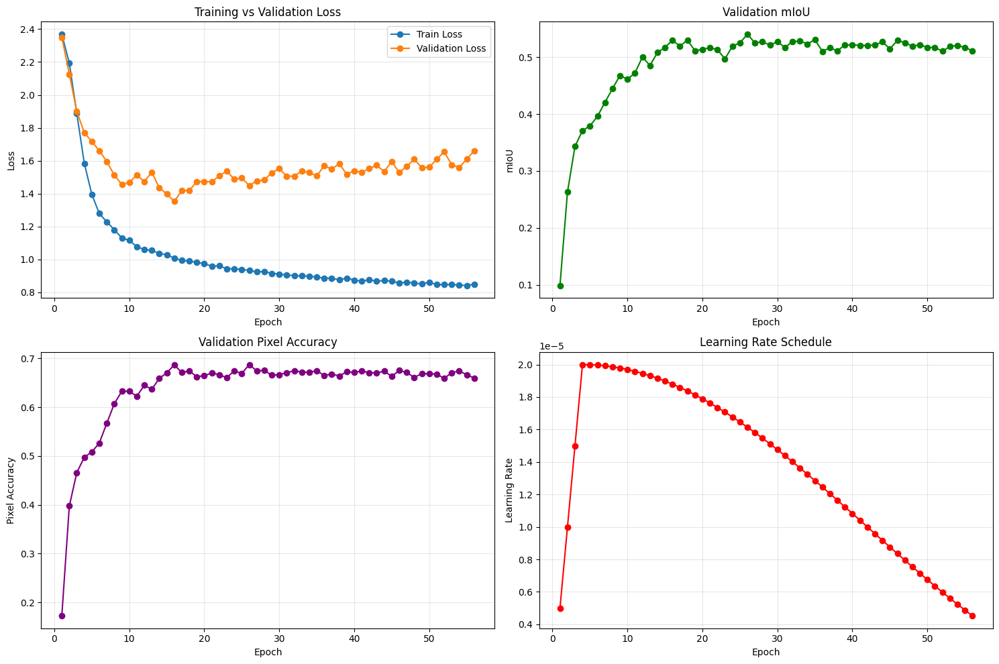

In [15]:
# =====================================================
# TRAINING CURVES
# =====================================================

epochs_range = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# -----------------------------------------------------
# Loss
# -----------------------------------------------------
axes[0, 0].plot(
    epochs_range,
    history["train_loss"],
    marker="o",
    label="Train Loss"
)

axes[0, 0].plot(
    epochs_range,
    history["val_loss"],
    marker="o",
    label="Validation Loss"
)

axes[0, 0].set_title("Training vs Validation Loss")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Loss")
axes[0, 0].grid(alpha=0.3)
axes[0, 0].legend()

# -----------------------------------------------------
# mIoU
# -----------------------------------------------------
axes[0, 1].plot(
    epochs_range,
    history["val_miou"],
    color="green",
    marker="o"
)

axes[0, 1].set_title("Validation mIoU")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("mIoU")
axes[0, 1].grid(alpha=0.3)

# -----------------------------------------------------
# Pixel Accuracy
# -----------------------------------------------------
axes[1, 0].plot(
    epochs_range,
    history["val_pixel_acc"],
    color="purple",
    marker="o"
)

axes[1, 0].set_title("Validation Pixel Accuracy")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Pixel Accuracy")
axes[1, 0].grid(alpha=0.3)

# -----------------------------------------------------
# Learning Rate
# -----------------------------------------------------
axes[1, 1].plot(
    epochs_range,
    history["lr"],
    color="red",
    marker="o"
)

axes[1, 1].set_title("Learning Rate Schedule")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("Learning Rate")
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    f"{CFG.OUT_DIR}/training_curves.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

## 14. Load best checkpoint & evaluate

In [16]:
ckpt = torch.load(CFG.CKPT_BEST, map_location=CFG.DEVICE)

model.load_state_dict(ckpt["model_state_dict"])

best_miou = ckpt.get("best_miou", ckpt.get("val_miou", 0.0))

print(
    f"Loaded best checkpoint from Epoch {ckpt['epoch']} "
    f"(Best mIoU = {best_miou:.4f})"
)

Loaded best checkpoint from Epoch 26 (Best mIoU = 0.5402)


## 15. Summary table (train vs val loss across epochs)

In [17]:
# =====================================================
# TRAINING SUMMARY
# =====================================================

summary_df = pd.DataFrame({
    "epoch": list(epochs_range),
    "train_loss": history["train_loss"],
    "val_loss": history["val_loss"],
    "val_mIoU": history["val_miou"],
    "val_pixel_acc": history["val_pixel_acc"],
    "learning_rate": history["lr"],
})

# Round values for better readability
summary_df = summary_df.round({
    "train_loss": 4,
    "val_loss": 4,
    "val_mIoU": 4,
    "val_pixel_acc": 4,
    "learning_rate": 8
})

# Save CSV
summary_df.to_csv(
    f"{CFG.OUT_DIR}/training_history.csv",
    index=False
)

print(f"Training history saved to: {CFG.OUT_DIR}/training_history.csv")

# Display the last 10 epochs
summary_df.tail(10)

Training history saved to: /kaggle/working/segformer_b2_loveda/training_history.csv


,epoch,train_loss,val_loss,val_mIoU,val_pixel_acc,learning_rate
46,47,0.8607,1.5656,0.5254,0.6713,0.000008
47,48,0.8571,1.6093,0.5192,0.6607,0.000008
48,49,0.8508,1.5579,0.5219,0.6687,0.000007
49,50,0.8610,1.5610,0.5170,0.6685,0.000007
50,51,0.8477,1.6089,0.5171,0.6677,0.000006
51,52,0.8464,1.6540,0.5102,0.6590,0.000006
52,53,0.8474,1.5758,0.5185,0.6706,0.000006
53,54,0.8433,1.5585,0.5206,0.6740,0.000005
54,55,0.8421,1.6090,0.5171,0.6665,0.000005
55,56,0.8486,1.6598,0.5112,0.6598,0.000005


In [18]:
print("Validation dataset size:", len(val_ds))

Validation dataset size: 677


## 16. Inference on 20 images (separate cell, uses best checkpoint)

In [19]:
import random
import torch
import torch.nn.functional as F

# =====================================================
# INFERENCE
# =====================================================

@torch.no_grad()
def run_inference(
    model,
    dataset,
    num_samples=30,
    seed=42
):

    model.eval()

    rng = random.Random(seed)

    # Number of images to sample
    num_samples = min(num_samples, len(dataset))

    indices = rng.sample(range(len(dataset)), num_samples)

    results = []

    for idx in indices:

        img_tensor, mask_tensor, fname = dataset[idx]

        inp = img_tensor.unsqueeze(0).to(CFG.DEVICE)

        with torch.amp.autocast(
            device_type="cuda",
            enabled=CFG.MIXED_PRECISION and torch.cuda.is_available()
        ):

            outputs = model(pixel_values=inp)

            logits = F.interpolate(
                outputs.logits,
                size=img_tensor.shape[-2:],
                mode="bilinear",
                align_corners=False
            )

            probs = torch.softmax(logits, dim=1)

        pred = probs.argmax(dim=1).squeeze(0).cpu().numpy()

        confidence = probs.max(dim=1)[0].mean().item()

        results.append({
            "fname": fname,
            "image": denormalize(img_tensor),
            "gt_mask": mask_tensor.numpy(),
            "pred_mask": pred,
            "confidence": confidence
        })

    return results


# =====================================================
# RUN INFERENCE
# =====================================================

NUM_SAMPLES = 30

infer_results = run_inference(
    model=model,
    dataset=val_ds,
    num_samples=NUM_SAMPLES,
    seed=SEED
)

print(f"Generated {len(infer_results)} inference samples.")

Generated 30 inference samples.


## 17. Visualize the 20 inference results (image | ground truth | prediction)



In [20]:
# =====================================================
# VISUALIZE INFERENCE RESULTS
# =====================================================

n = len(infer_results)

fig, axes = plt.subplots(
    n,
    3,
    figsize=(12, 3.5 * n)
)

if n == 1:
    axes = np.expand_dims(axes, axis=0)

for i, result in enumerate(infer_results):

    # ------------------------
    # Original Image
    # ------------------------
    axes[i, 0].imshow(result["image"])
    axes[i, 0].set_title(
        result["fname"],
        fontsize=9,
        fontweight="bold"
    )
    axes[i, 0].axis("off")

    # ------------------------
    # Ground Truth
    # ------------------------
    axes[i, 1].imshow(
        mask_to_rgb(
            result["gt_mask"],
            CFG.IGNORE_INDEX
        )
    )

    axes[i, 1].set_title(
        "Ground Truth",
        fontsize=9
    )

    axes[i, 1].axis("off")

    # ------------------------
    # Prediction
    # ------------------------
    axes[i, 2].imshow(
        mask_to_rgb(
            result["pred_mask"],
            CFG.IGNORE_INDEX
        )
    )

    axes[i, 2].set_title(
        f"Prediction\nConf: {result['confidence']:.2f}",
        fontsize=9
    )

    axes[i, 2].axis("off")


# =====================================================
# LEGEND
# =====================================================

legend_patches = [

    mpatches.Patch(
        color=np.array(color) / 255,
        label=name
    )

    for color, name in zip(CLASS_COLORS, CLASS_NAMES)

]

fig.legend(
    handles=legend_patches,
    loc="lower center",
    ncol=len(CLASS_NAMES),
    fontsize=9,
    bbox_to_anchor=(0.5, -0.01)
)

plt.tight_layout(rect=[0, 0.05, 1, 1])

plt.savefig(
    f"{CFG.OUT_DIR}/inference_results.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()